### Analyze Post-Optimization results for a single run 

**stochastic model with scenario tree for long-term demand uncertainty and using only a subset of weeks each representative year**

# Data reading and setup

In [1]:
# Import python modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
# Now this works because Python sees `src` as a top-level module
from src import analytics, plotting, utils

In [3]:
import yaml

In [4]:
# Notebook input parameters
SAVE_FIGURES = False
SAVE_TABLES = False
show_plots = False
folder_name = "XXX4weeks_1core___"

In [ ]:
FOLDER = os.path.join(
    os.path.dirname(os.getcwd()),
    "runs",
    "single_runs",
    folder_name,
)
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\1_May16_Fri_h23_m07_s45-GTSEP_stochastic_v1-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\2_May17_Sat_h00_m00_s46-GTSEP_stochastic_v1-128_ES_PT_no_bat"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_4_weeks_efs_ramping\1_May22_Thu_h20_m54_s05-GTSEP_stochastic_v2-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_sv1_ef05_dc\1_May22_Thu_h15_m32_s51-GTSEP_stochastic_v1-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_4_weeks_efs_ramping\1_May23_Fri_h13_m41_s29-GTSEP_stochastic_v2-128_ES_PT"
decision_variables_folder = os.path.join(FOLDER, "decision_variables")
model_info_folder = os.path.join(FOLDER, "model_info")
dual_variables_folder = os.path.join(FOLDER, "dual_variables")

In [6]:
RESULTS_FOLDER = os.path.join(FOLDER, "results")
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)
if SAVE_TABLES:
    tables_folder = os.path.join(RESULTS_FOLDER, "tables")
    if not os.path.exists(tables_folder):
        os.makedirs(tables_folder)
else:
    tables_folder = None
if SAVE_FIGURES:
    figures_folder = os.path.join(RESULTS_FOLDER, "figures")
    if not os.path.exists(figures_folder):
        os.makedirs(figures_folder)
else:
    figures_folder = None

In [7]:
# Color mapping for scenarios (reuse for other plots)
scenario_colors = {
    "NT": "#1f77b4",
    "GA": "#ff7f0e",
    "DE": "#2ca02c",
    "Average": "#7f7f7f",
}

# Define a consistent color palette for cost categories
category_colors = {
    "Invest Gen": "#b20000",  # dark red
    "Invest Bat": "#0072b2",  # blue
    "Invest Tx": "#009e73",  # green
    "Prod Cost": "#f0e442",  # yellow
    "CO₂ Cost": "#d55e00",  # orange
    "Load Shedding Cost": "#cc79a7",  # magenta
    "Curtailment Cost": "#56b4e9",  # light blue
}

## Read data

In [8]:
model_info = pd.read_csv(os.path.join(model_info_folder, "model_info.csv"))
config = yaml.safe_load(open(os.path.join(model_info_folder, "config.yaml")))
jsons = utils.read_jsons_from_dir(model_info_folder)

In [9]:
scenarios = jsons["scenarios"]
scenario_probabilities = jsons["scenario_probabilities"]
week_weights = jsons["week_weights"]

In [10]:
data_folder_name = config["data_folder_name"]
VOLL = config["VOLL"]
CC = config["CC"]
CO2_price = config["CO2_price"]
E_limit = config["E_limit"]
p_max_new_branch = config["p_max_new_branch"]
p_min_new_branch = config["p_min_new_branch"]
expansion_factor = config["expansion_factor"]
MS = config["MS"]
model_name = config["model_name"]
MIPGap = config["MIPGap"]
years = config["years"]
r = config["discount_rate"]
representative_period_unit = config["representative_period_unit"]
weeks = config["representative_periods"]
scenario_file = config["scenario_file"]
yearly_discount = config.get("yearly_discount", 10)

In [11]:
input_data_folder = os.path.join(
    os.path.dirname(os.getcwd()), "data", "processed", config["data_folder_name"]
)
input_data = utils.load_multi_year_csv_files_with_week_from_folder(
    years=years, data_folder_path=input_data_folder, yearly_discount=yearly_discount
)
scenario_multiplier = utils.load_scenario_multiplier(scenario_file_name=scenario_file)

**Note:** The input data is such that all data is the same for all years. All the data that is year-dependent has year as index. The only exception is the demand data, which does not have copies for years.

In [12]:
dual_variables = utils.load_csv_files_from_folder_with_scenarios(dual_variables_folder)
decision_varables = utils.load_csv_files_from_folder_with_scenarios(
    decision_variables_folder
)

In [13]:
print("Input data")
for data_type in input_data.keys():
    print(f"{data_type}")
print()
print("Decision variables:")
for decision_variable in decision_varables.keys():
    print(decision_variable)
print()
print("Dual variables:")
for dual_variable in dual_variables.keys():
    print(dual_variable)

Input data
batteries
branches
capacity_factors
generators
generator_costs
hourly_demand
nodes

Decision variables:
battery_capacity
battery_charging
battery_discharging
battery_soc
branch_capacity
curtailment
generation
generator_capacity
load_shedding
power_flow

Dual variables:
battery_charge_new_max_duals
battery_charge_old_duals
battery_discharge_new_max_duals
battery_discharge_old_duals
branch_extension_duals
branch_flow_new_duals_max
branch_flow_new_duals_min
branch_flow_old_duals_max
branch_flow_old_duals_min
emissions_duals
gen_extension_duals
gen_output_new_duals
gen_output_old_duals
load_shedding_duals
power_balance_duals


In [14]:
decision_varables

{'battery_capacity':                        value
 battery   year              
 ES1 0 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 1 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 2 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 3 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 4 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 5 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 6 bat 2025    935.349400
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 7 bat 2025  12292.560327
           2030      0.000000
           2040     

In [15]:
# read dataframes
# input data
batteries = input_data["batteries"]
branches = input_data["branches"]
generators = input_data["generators"]
capacity_factors = input_data["capacity_factors"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]
# decision variables
battery_capacity = decision_varables["battery_capacity"]
battery_charging = decision_varables["battery_charging"]
battery_discharging = decision_varables["battery_discharging"]
battery_soc = decision_varables["battery_soc"]
branch_capacity = decision_varables["branch_capacity"]
curtailment = decision_varables["curtailment"]
generation = decision_varables["generation"]
generator_capacity = decision_varables["generator_capacity"]
load_shedding = decision_varables["load_shedding"]
power_flow = decision_varables["power_flow"]

## Generators analysis

### Generators preprocessing

In [16]:
config["expansion_factor"]

0.5

In [17]:
generators["extension_potential"] = generators["p_nom"] * config["expansion_factor"]

In [18]:
# Example usage:
generators = analytics.add_capacity_and_cumulative_metrics(
    generators, generator_capacity
)

In [19]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,1712.650000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99017.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,3425.300000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99007.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,5137.950000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98997.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,6850.600000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,534.262466,0.000000,0.000000,534.262466,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,299110.224929,0.00,#4adbc8,Run of River,True,134.800000,0.000000,269.600000,539.200000,539.200000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,324.036799,324.036799,972.110398
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35592.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,648.073599,648.073599,1296.147198


### Generator Investment and Capacity Plots 

In [20]:
if SAVE_FIGURES:
    generators_save_folder = os.path.join(figures_folder, "generators")
    if not os.path.exists(generators_save_folder):
        os.makedirs(generators_save_folder)
else:
    generators_save_folder = None

if SAVE_TABLES:
    generators_save_table_folder = os.path.join(tables_folder, "generators")
    if not os.path.exists(generators_save_table_folder):
        os.makedirs(generators_save_table_folder)
else:
    generators_save_table_folder = None

Annual Capacity Investments by Technology


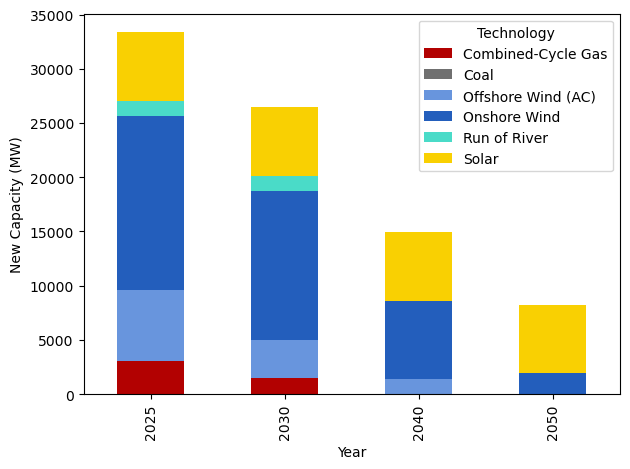

In [21]:
analytics.plot_capacity_investment_by_carrier(generators, generators_save_folder)

Annual Capital Expenditure by Technology


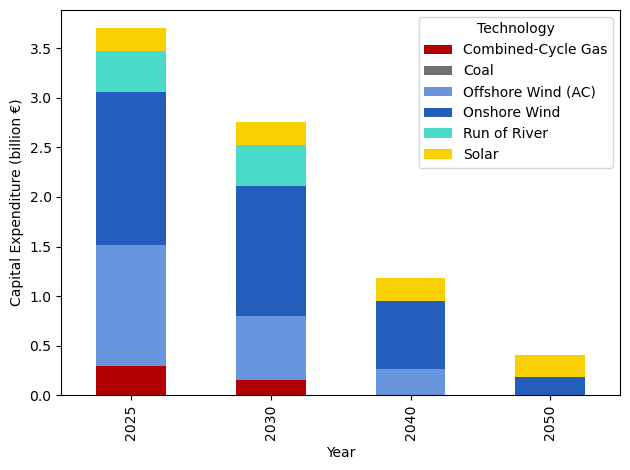

In [22]:
analytics.plot_capacity_spending_by_carrier(generators, generators_save_folder)

Growth in Total Installed Capacity


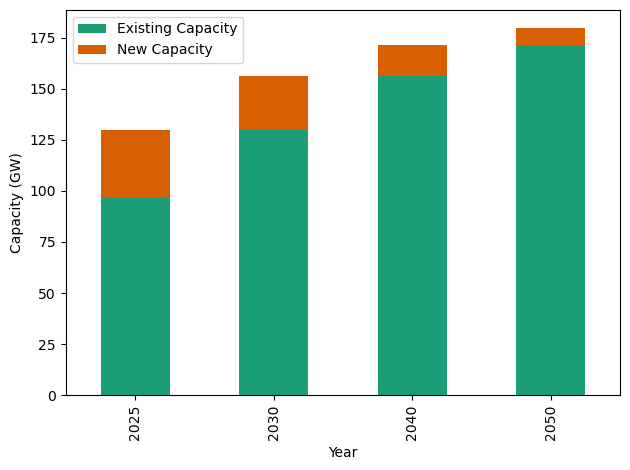

In [23]:
analytics.plot_total_capacity_growth(generators, generators_save_folder)

Extension Potential vs Actual New Capacity by Technology


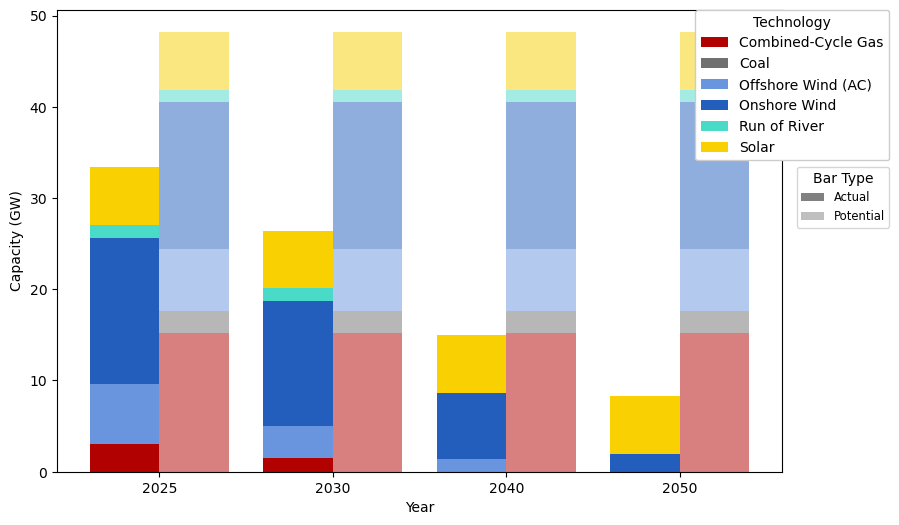

In [24]:
analytics.plot_extension_vs_potential_by_carrier(generators, generators_save_folder)

### Generators Production and Time Series Plots

In [25]:
production_by_carrier_table = analytics.create_energy_production_by_carrier_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    savefolder=generators_save_table_folder,
)
production_by_carrier_table


Annual expected energy production by carrier (scenario-weighted):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar
year,,,,,,
2025,8.915808e+07,7.036831e+06,4.330095e+07,8.948662e+07,1.915410e+07,2.579712e+07
2030,7.462992e+07,4.623587e+06,4.935100e+07,1.047989e+08,2.553880e+07,3.439617e+07
2040,9.316452e+07,7.824742e+06,5.512502e+07,1.257543e+08,2.553880e+07,4.299521e+07
2050,9.926619e+07,8.937916e+06,5.568593e+07,1.327393e+08,2.553880e+07,5.159425e+07


In [26]:
annual_production_table = analytics.make_annual_production_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
annual_production_table

Annual expected energy production by carrier and scenario (MWh):


carrier                CCGT          coal    offwind-ac        onwind  \
year scenario                                                           
2025 NT        8.915808e+07  7.036831e+06  4.330095e+07  8.948662e+07   
2030 NT        7.462992e+07  4.623587e+06  4.935100e+07  1.047989e+08   
2040 DE        3.456759e+07  3.140288e+06  1.872679e+07  4.301621e+07   
     GA        2.593694e+07  1.833272e+06  1.787735e+07  4.022377e+07   
     NT        3.265999e+07  2.851182e+06  1.852088e+07  4.251436e+07   
2050 DE        5.684673e+07  5.671330e+06  2.845790e+07  6.857914e+07   
     GA        4.241945e+07  3.266586e+06  2.722803e+07  6.416012e+07   

carrier                 ror         solar         Total  
year scenario                                            
2025 NT        1.915410e+07  2.579712e+07  2.739337e+08  
2030 NT        2.553880e+07  3.439617e+07  2.933384e+08  
2040 DE        8.512935e+06  1.433174e+07  1.222956e+08  
     GA        8.512935e+06  1.433174e+07  1.087160e+08  
     NT        8.512935e+06  1.433174e+07  1.193911e+08  
2050 DE        1.276940e+07  2.579712e+07  1.981216e+08  
     GA        1.276940e+07  2.579712e+07  1.756407e+08

In [27]:
annual_cost_table = analytics.make_weighted_annual_production_cost_by_year_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    carbon_price=CO2_price,
    savefolder=generators_save_table_folder,
)
annual_cost_table

Annual scenario-weighted production cost (incl. CO₂) by technology (EUR):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,4.895161e+09,3.898191e+08,649514.177126,1.342299e+06,0.0,257971.242230,5.287230e+09
2030,4.097891e+09,2.561327e+08,740264.932052,1.571983e+06,0.0,343961.656306,4.356679e+09
2040,5.122400e+09,4.334670e+08,826875.332410,1.886315e+06,0.0,429952.070383,5.559010e+09
2050,5.466255e+09,4.951334e+08,835288.906481,1.991089e+06,0.0,515942.484459,5.964731e+09


In [28]:
weighted_annual_production_by_year = analytics.make_weighted_annual_production_by_year(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
weighted_annual_production_by_year

Annual scenario-weighted energy production by carrier (MWh):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,8.915808e+07,7.036831e+06,4.330095e+07,8.948662e+07,1.915410e+07,2.579712e+07,2.739337e+08
2030,7.462992e+07,4.623587e+06,4.935100e+07,1.047989e+08,2.553880e+07,3.439617e+07,2.933384e+08
2040,9.316452e+07,7.824742e+06,5.512502e+07,1.257543e+08,2.553880e+07,4.299521e+07,3.504026e+08
2050,9.926619e+07,8.937916e+06,5.568593e+07,1.327393e+08,2.553880e+07,5.159425e+07,3.737623e+08


Evolution of Annual Energy Production by Technology (averaged across scenarios)


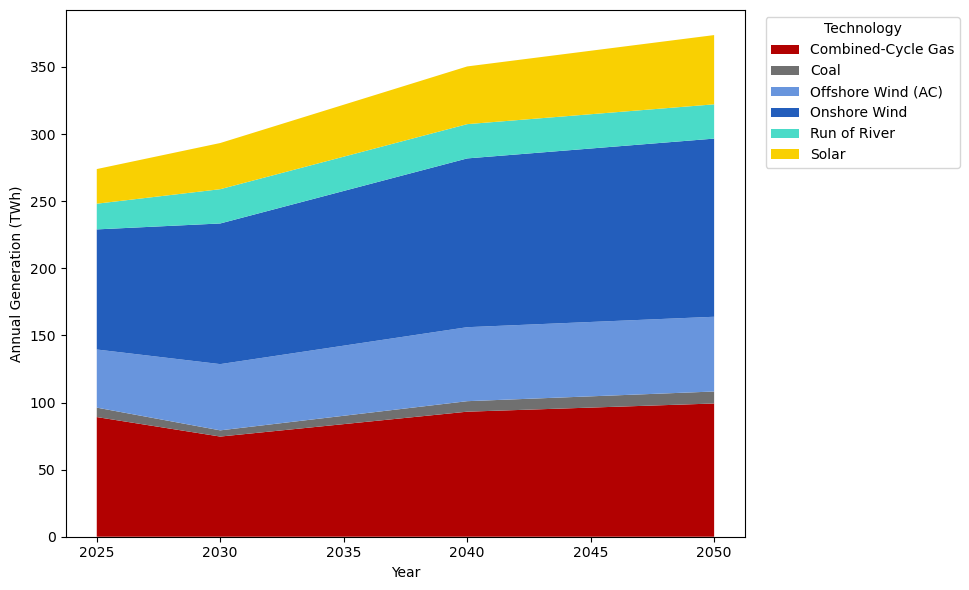

Evolution of Annual Energy Production by Technology (averaged across scenarios)


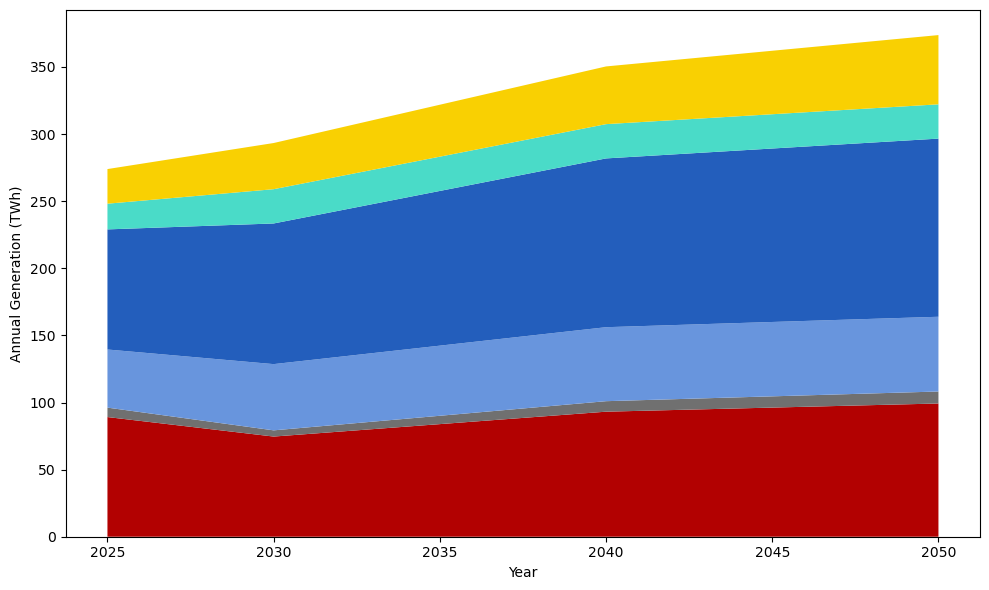

In [29]:
analytics.plot_weighted_production_evolution(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

analytics.plot_weighted_production_evolution_no_legend(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

Evolution of Annual Production Cost including CO₂ Emissions by Technology


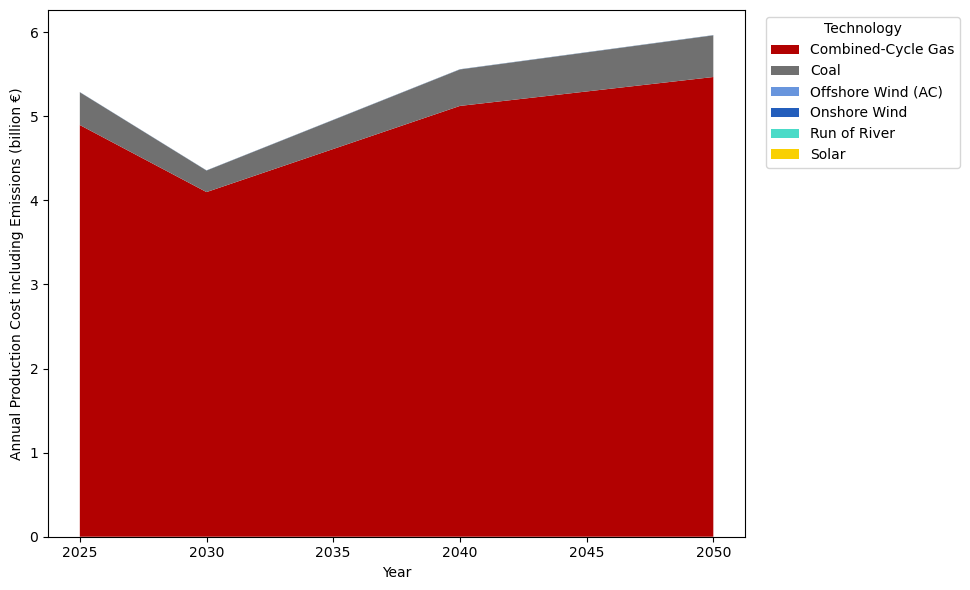

In [30]:
analytics.plot_weighted_production_cost_evolution(
    annual_cost_table, generators, savefolder=generators_save_folder
)

In [31]:
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, generators_save_table_folder
)
yearly_system_cost_table

Yearly system metrics by year and scenario:


production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.739337e+08  2.022414e+07       1.617931e+09     3.669299e+09   
2030 NT        2.933384e+08  1.649800e+07       1.319840e+09     3.036839e+09   
2040 DE        3.668867e+08  2.394365e+07       1.915492e+09     4.314067e+09   
     GA        3.261480e+08  1.743210e+07       1.394568e+09     3.188416e+09   
     NT        3.581732e+08  2.250420e+07       1.800336e+09     4.064151e+09   
2050 DE        3.962433e+08  2.659520e+07       2.127616e+09     4.772991e+09   
     GA        3.512814e+08  1.918906e+07       1.535125e+09     3.493730e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         5.287230e+09  
2030 NT                         4.356679e+09  
2040 DE                         6.229559e+09  
     GA                         4.582984e+09  
     NT                         5.864487e+09  
2050 DE                         6.900607e+09  
     GA                         5.028855e+09

CO₂ Emissions by Year and Scenario


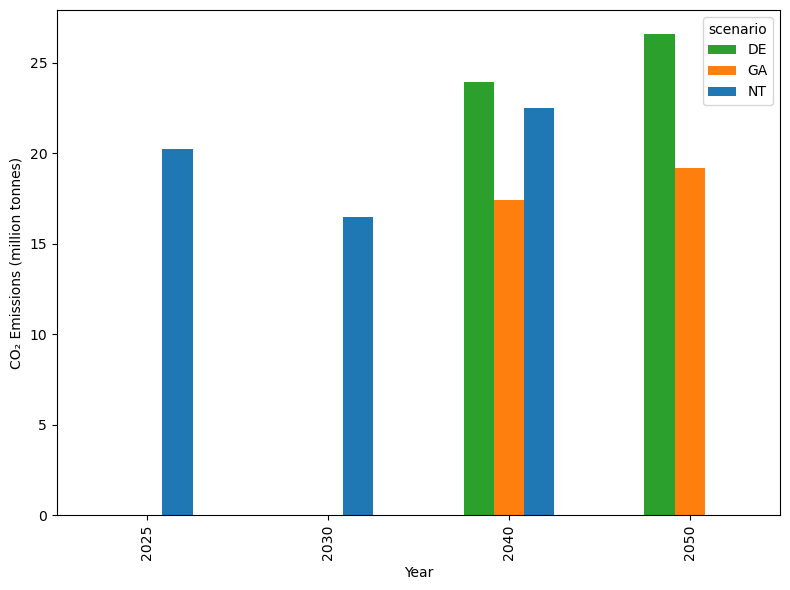

CO₂ Emissions by Year, Scenario, and Average


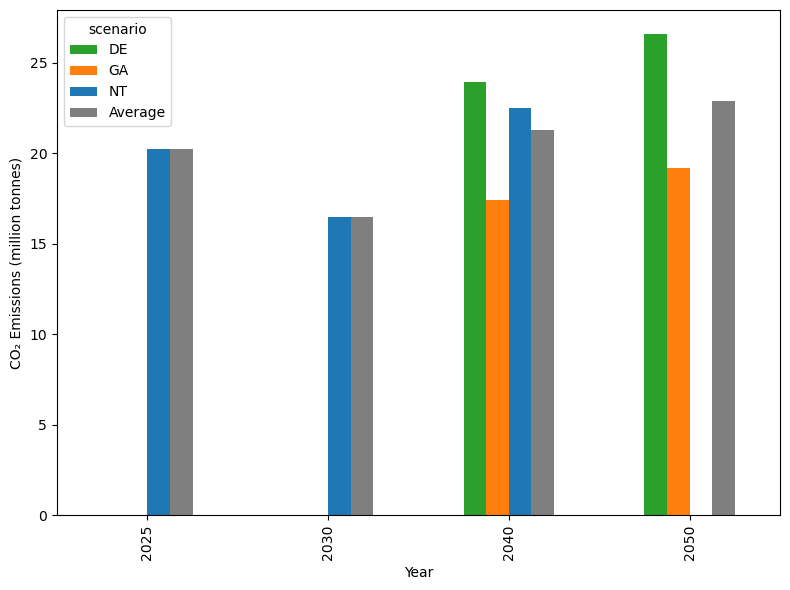

Annual Production by Year, Scenario, and Average


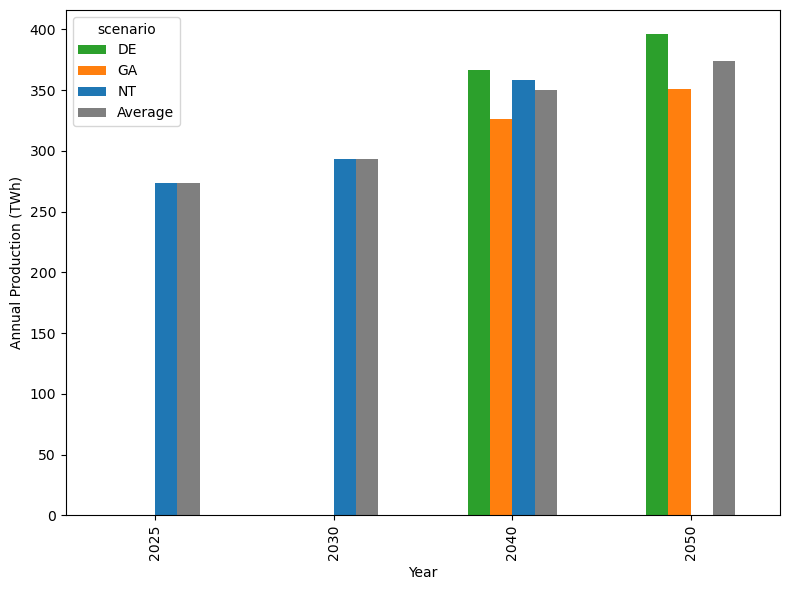

Production Cost by Year, Scenario, and Average


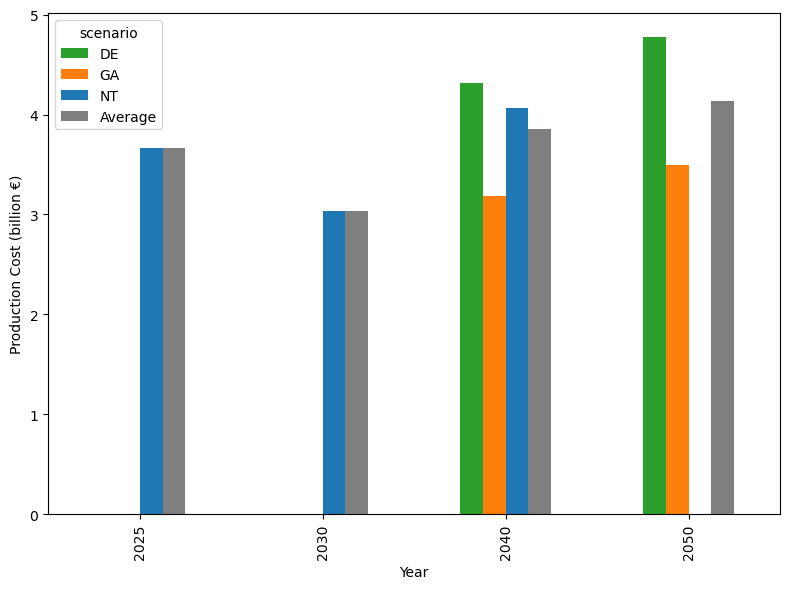

Production Cost w/ Emissions by Year, Scenario, and Average


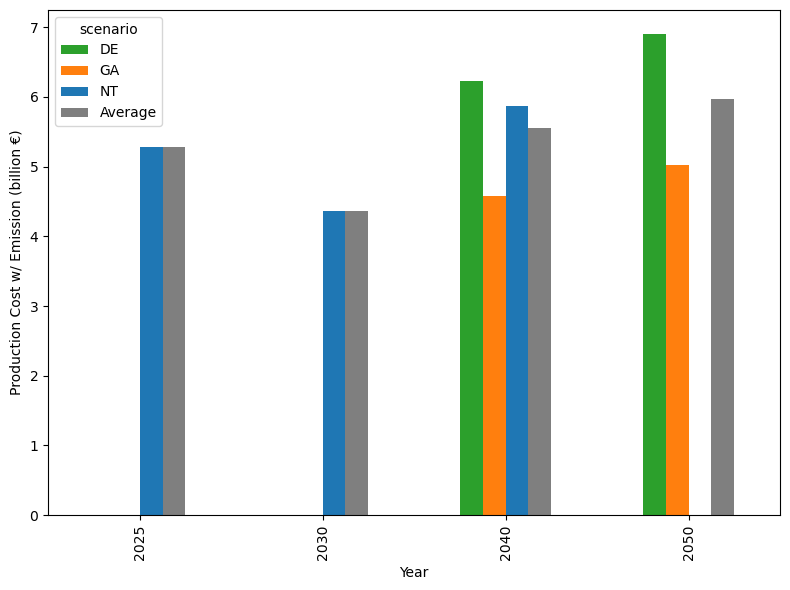

In [32]:
analytics.plot_co2_emissions_by_scenario(
    yearly_system_cost_table, savefolder=generators_save_folder
)
analytics.plot_co2_emissions_by_scenario_avg(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_by_scenario(yearly_system_cost_table, generators_save_folder)
analytics.plot_production_cost_by_scenario(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_cost_with_emission_by_scenario(
    yearly_system_cost_table, generators_save_folder
)

In [33]:
# if figures_folder:
#     generation_curves_folder = os.path.join(figures_folder, "generation_curves")
#     os.makedirs(generation_curves_folder, exist_ok=True)
# else:
#     generation_curves_folder = None

# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# carriers = generators.reset_index()["carrier"].unique()

# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             for carrier in carriers:
#                 analytics.plot_fraction_of_max_generation_by_carrier(
#                     generation,
#                     capacity_factors,
#                     generators,
#                     year,
#                     week,
#                     scen,
#                     carrier,
#                     savefolder=generation_curves_folder,  # or None if you don’t want to save
#                 )

In [34]:
# # loop over combinations
# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             analytics.plot_utilization_time_series_by_carrier(
#                 generation,
#                 capacity_factors,
#                 generators,
#                 year,
#                 week,
#                 scen,
#                 savefolder=tables_folder,
#             )

In [35]:
scenarios

{'2025': ['NT'],
 '2030': ['NT'],
 '2040': ['NT', 'GA', 'DE'],
 '2050': ['GA', 'DE']}

capacity_factors shape: (35040, 51)
cf_weekly shape: (208, 51)
weighted_cf shape: (208, 51)
annual_cf shape: (4, 51)
cap_df shape: (4, 51)
Sample of potential_car: carrier          CCGT          coal    offwind-ac        onwind           ror  \
year                                                                            
2025     2.932086e+08  4.151709e+07  5.186394e+07  1.075012e+08  1.915410e+07   
2030     3.063661e+08  4.151709e+07  6.261123e+07  1.399234e+08  2.553880e+07   
2040     3.063661e+08  4.151709e+07  6.804585e+07  1.596374e+08  2.553880e+07   
2050     3.063661e+08  4.151709e+07  6.804585e+07  1.657073e+08  2.553880e+07   

carrier         solar  
year                   
2025     2.579712e+07  
2030     3.439617e+07  
2040     4.299521e+07  
2050     5.159425e+07  
potential shape: (4, 51)
Sample of capacity_factors:                 ES1 0 offwind-ac  ES1 0 onwind  ES1 0 solar  ES1 1 offwind-ac  \
year week hour                                                         

c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2491: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  actual_car = actual.groupby(gen2car, axis=1).sum()  # (year,scenario)×carrier
c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2492: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  potential_car = potential.groupby(gen2car, axis=1).sum()  # year×carrier


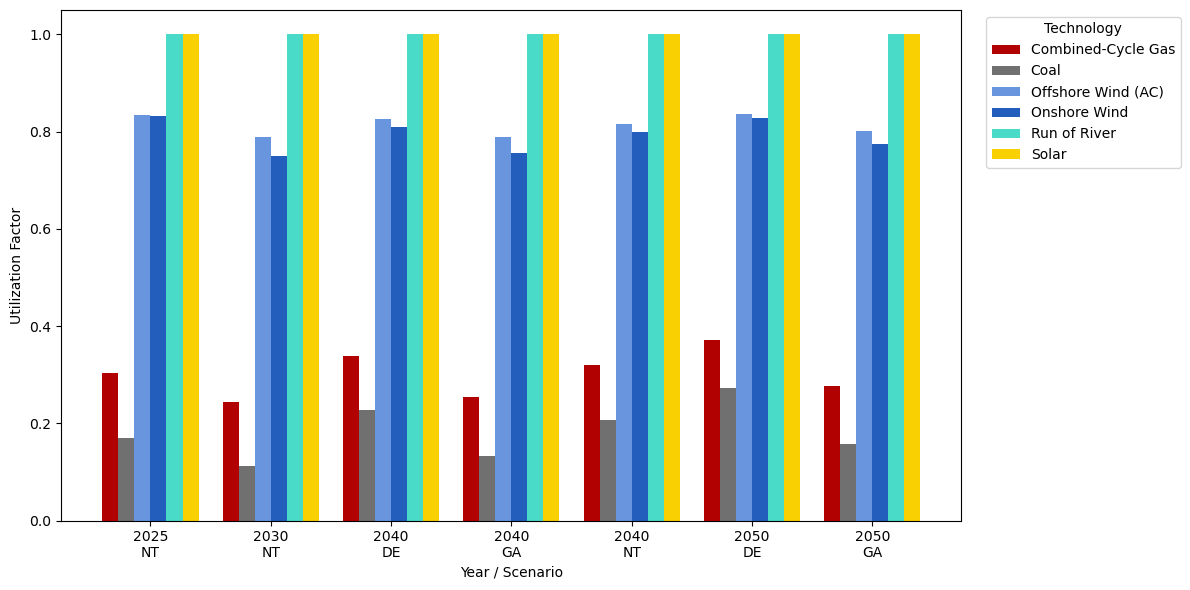

In [36]:
analytics.plot_utilization_hierarchy(
    generation,
    capacity_factors,
    generators,
    week_weights,
    scenarios,
    savefolder=generators_save_folder,
)

In [37]:
summary_table = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=tables_folder,
)

In [38]:
summary_table

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,48228.204285,33399.156266,51,38,3.700676e+09,2.739337e+08,2.022414e+07,1.617931e+09,3.669299e+09,5.287230e+09,8.987906e+09
2030,48228.204285,26440.225829,51,30,2.753993e+09,2.933384e+08,1.649800e+07,1.319840e+09,3.036839e+09,4.356679e+09,7.110672e+09
2040,48228.204285,14971.160576,51,18,1.179938e+09,3.504026e+08,2.129332e+07,1.703465e+09,3.855545e+09,5.559010e+09,6.738948e+09
2050,48228.204285,8270.018234,51,12,4.100994e+08,3.737623e+08,2.289213e+07,1.831370e+09,4.133360e+09,5.964731e+09,6.374830e+09


In [39]:
summary_by_carrier_table = analytics.make_system_summary_table_by_carrier(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    tables_folder,
)
summary_by_carrier_table

potential_capacity  new_capacity  number_possible_buildouts  \
year carrier                                                                   
2025 CCGT              15225.166000   3020.971702                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111   6612.169132                          9   
     onwind            16019.751672  16019.751672                         11   
     ror                1392.754124   1392.754124                          4   
     solar              6353.509637   6353.509637                         11   
2030 CCGT              15225.166000   1502.000000                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111   3510.341607                          9   
     onwind            16019.751672  13681.620462                         11   
     ror                1392.754124   1392.754124                          4   
     solar              6353.509637   6353.509637                         11   
2040 CCGT              15225.166000      0.000000                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111   1437.551690                          9   
     onwind            16019.751672   7180.099250                         11   
     ror                1392.754124      0.000000                          4   
     solar              6353.509637   6353.509637                         11   
2050 CCGT              15225.166000      0.000000                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111      0.000000                          9   
     onwind            16019.751672   1916.508598                         11   
     ror                1392.754124      0.000000                          4   
     solar              6353.509637   6353.509637                         11   

                 number_actual_buildouts  cost_of_buildout  total_production  \
year carrier                                                                   
2025 CCGT                              4      2.991600e+08      8.915808e+07   
     coal                              0      0.000000e+00      7.036831e+06   
     offwind-ac                        8      1.219417e+09      4.330095e+07   
     onwind                           11      1.539272e+09      8.948662e+07   
     ror                               4      4.166288e+08      1.915410e+07   
     solar                            11      2.261981e+08      2.579712e+07   
2030 CCGT                              1      1.487246e+08      7.462992e+07   
     coal                              0      0.000000e+00      4.623587e+06   
     offwind-ac                        5      6.480447e+08      4.935100e+07   
     onwind                            9      1.314474e+09      1.047989e+08   
     ror                               4      4.166149e+08      2.553880e+07   
     solar                            11      2.261346e+08      3.439617e+07   
2040 CCGT                              0      0.000000e+00      9.316452e+07   
     coal                              0      0.000000e+00      7.824742e+06   
     offwind-ac                        2      2.641039e+08      5.512502e+07   
     onwind                            5      6.897626e+08      1.257543e+08   
     ror                               0      0.000000e+00      2.553880e+07   
     solar                            11      2.260710e+08      4.299521e+07   
2050 CCGT                              0      0.000000e+00      9.926619e+07   
     coal                              0      0.000000e+00      8.937916e+06   
     offwind-ac                        0      0.000000e+00      5.568593e+07   
     onwind                            1      1.840919e+08      1.327393e+08   
     ror        

## Transmission Lines

In [40]:
# Preprocessing
if "extended_by" in branches.columns:
    branches.drop(columns=["extended_by"], inplace=True)
if "branch" in branch_capacity.index.names:
    branch_capacity = branch_capacity.rename_axis(index={"branch": "line"})
if "branch" in power_flow.index.names:
    power_flow = power_flow.rename_axis(index={"branch": "line"})
branches["extension_potential"] = p_max_new_branch

In [41]:
if SAVE_FIGURES:
    branches_save_folder = os.path.join(figures_folder, "branches")
    if not os.path.exists(branches_save_folder):
        os.makedirs(branches_save_folder)
else:
    branches_save_folder = None
if SAVE_TABLES:
    branches_save_table_folder = os.path.join(tables_folder, "branches")
    if not os.path.exists(branches_save_table_folder):
        os.makedirs(branches_save_table_folder)
else:
    branches_save_table_folder = None

In [42]:
branches = analytics.extend_branches_table(branches, branch_capacity)

In [43]:
branches["capital_cost"]

year  line
2025  88      23102.962586
2030  88      23092.962586
2040  88      23082.962586
2050  88      23072.962586
2025  89      11729.199350
                  ...     
2050  107     22031.025373
2025  219     14480.882016
2030  219     14470.882016
2040  219     14460.882016
2050  219     14450.882016
Name: capital_cost, Length: 76, dtype: float64

Annual New Branch Capacity Additions


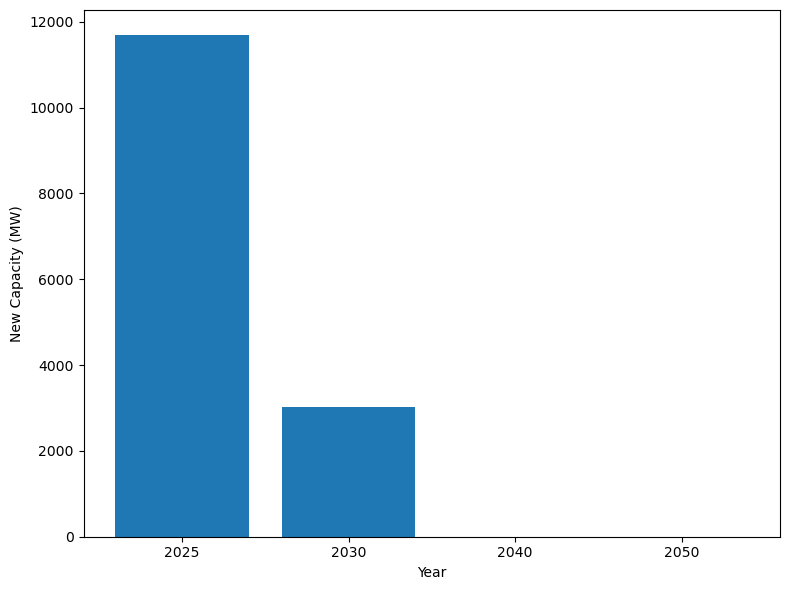

In [44]:
analytics.plot_branch_new_capacity(branches, savefolder=branches_save_folder)

In [45]:
branch_buildout_summary = analytics.make_branch_buildout_summary(
    branches, savefolder=branches_save_table_folder
)


branch_buildout_summary

Branch buildout summary by year:


,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,11689.704453,19,3,2.009912e+08
2030,95000,3021.753808,19,1,3.964995e+07
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [46]:
branch_flow_table_per_line = analytics.make_branch_flow_metrics(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_table_per_line

utilization_rate  congestion_rate
line scenario year                                   
88   DE       2040          0.972949         0.852679
              2050          0.971678         0.830357
     GA       2040          0.984721         0.912202
              2050          0.981598         0.895833
     NT       2025          0.981462         0.912202
...                              ...              ...
219  GA       2040          0.808181         0.247024
              2050          0.801542         0.276786
     NT       2025          0.726650         0.044643
              2030          0.825578         0.273810
              2040          0.811823         0.261905

[133 rows x 2 columns]

In [47]:
branch_flow_summary = analytics.make_aggregate_branch_flow_summary(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_summary

utilization_rate  congestion_rate
year scenario                                   
2025 NT                0.636675         0.515508
2030 NT                0.661762         0.513001
2040 DE                0.663328         0.519815
     GA                0.661823         0.512453
     NT                0.662980         0.517387
2050 DE                0.663407         0.523418
     GA                0.661037         0.518875

Transmission line investments in 2025:


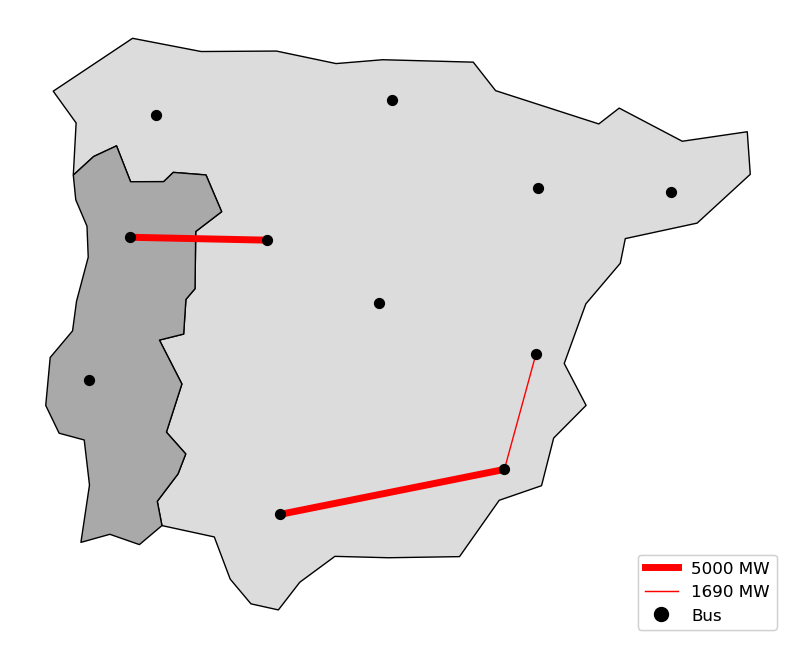

Plotting grid with new branches in year 2025
Transmission line investments in 2030:


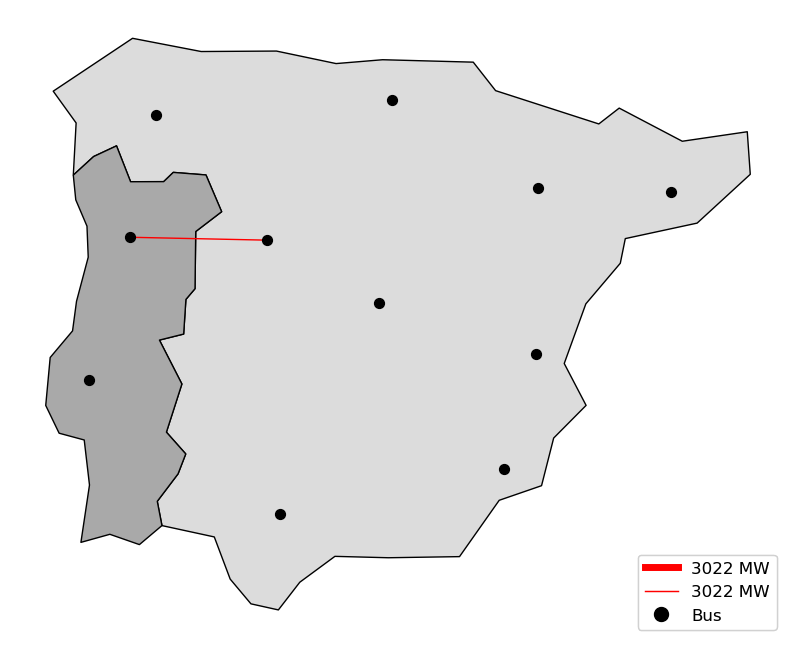

Plotting grid with new branches in year 2030


In [48]:
analytics.plot_new_branches_for_years_with_investments(
    branches, branch_capacity, nodes, savefolder=branches_save_folder
)

## Batteries

In [49]:
if SAVE_FIGURES:
    batteries_save_folder = os.path.join(figures_folder, "batteries")
    if not os.path.exists(batteries_save_folder):
        os.makedirs(batteries_save_folder)
else:
    batteries_save_folder = None
if SAVE_TABLES:
    batteries_save_table_folder = os.path.join(tables_folder, "batteries")
    if not os.path.exists(batteries_save_table_folder):
        os.makedirs(batteries_save_table_folder)
else:
    batteries_save_table_folder = None

Annual Battery Capacity Investments


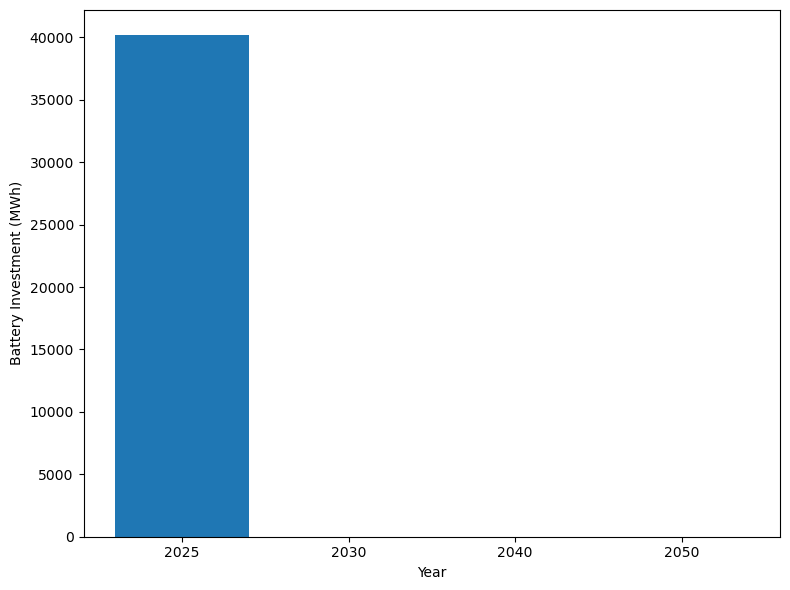

Annual Battery Investment Cost (million €)


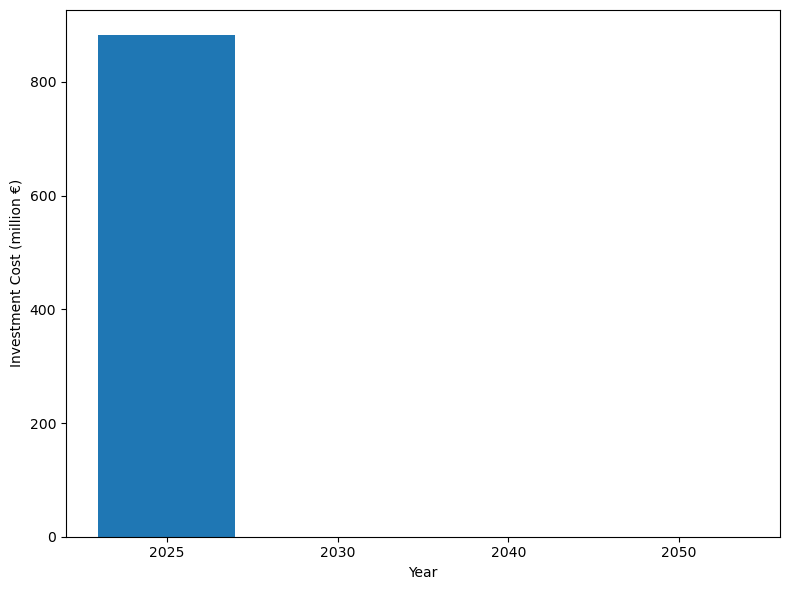

Number of 320 MWh Cycles by Year, Scenario, and Average


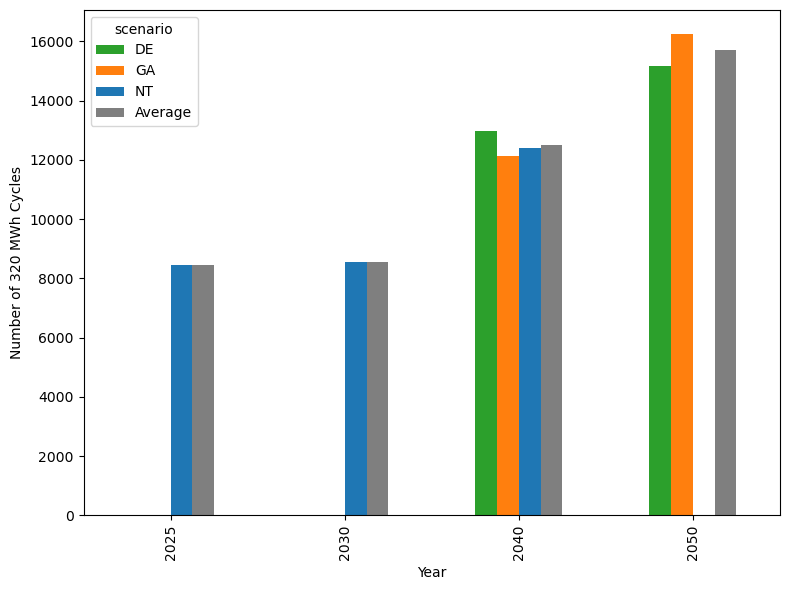

In [50]:
if len(batteries) > 0:
    batteries = analytics.extend_batteries_table(batteries.copy(), battery_capacity)
    analytics.plot_battery_investment_by_year(
        batteries, savefolder=batteries_save_folder
    )
    analytics.plot_battery_investment_cost_by_year(
        batteries, savefolder=batteries_save_folder
    )
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        batteries_save_table_folder,
    )
    analytics.plot_cycles_per_scenario_with_average(
        battery_discharging,
        week_weights,
        reference_cycle_mwh=400 * (0.8),
        savefolder=batteries_save_folder,
    )
    battery_summary

In [51]:
battery_summary

,num_buildout,capacity,cumulative_capacity,investment_cost,cycles_per_year
year,,,,,
2025,3,40177.842751,40177.842751,8.822622e+08,67.421573
2030,0,0.000000,40177.842751,0.000000e+00,68.138482
2040,0,0.000000,40177.842751,0.000000e+00,99.580895
2050,0,0.000000,40177.842751,0.000000e+00,125.171136


Annual Curtailment by Year and Scenario


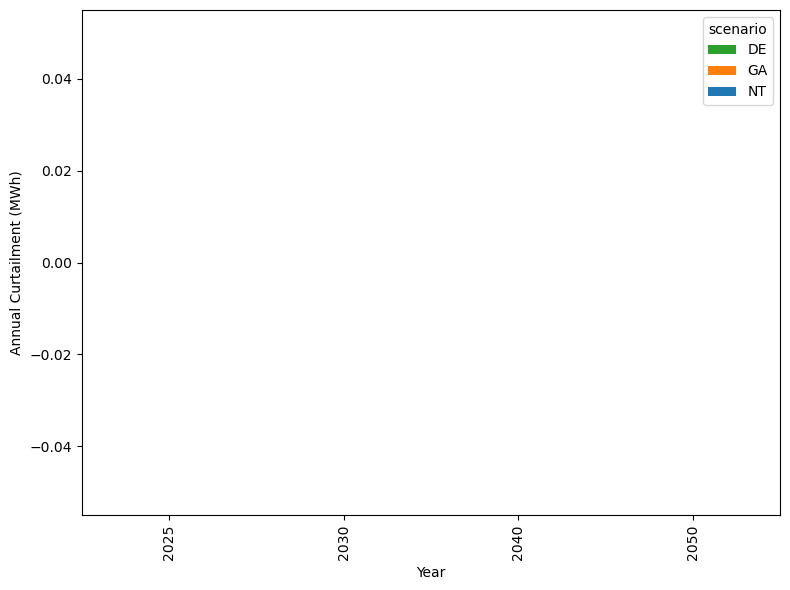

Annual Load Shedding by Year and Scenario


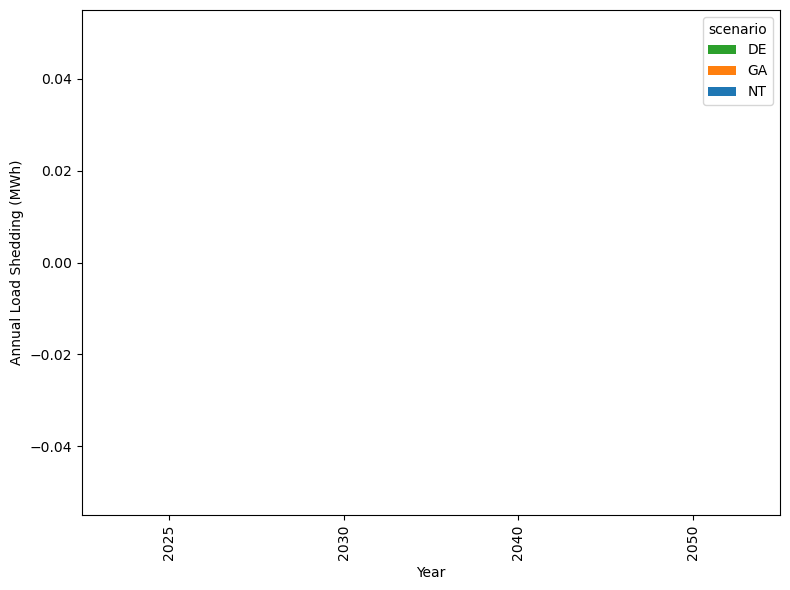

In [52]:
analytics.plot_curtailment_by_scenario(
    curtailment, week_weights, savefolder=figures_folder
)


analytics.plot_load_shedding_by_scenario(
    load_shedding, week_weights, savefolder=figures_folder
)

In [53]:
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT                  0.0          0.0                 0.0   
2030 NT                  0.0          0.0                 0.0   
2040 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   
     NT                  0.0          0.0                 0.0   
2050 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

## Macro analysis

In [54]:
if SAVE_FIGURES:
    macro_save_folder = os.path.join(figures_folder, "macro")
    if not os.path.exists(macro_save_folder):
        os.makedirs(macro_save_folder)
else:
    macro_save_folder = None
if SAVE_TABLES:
    macro_save_table_folder = os.path.join(tables_folder, "macro")
    if not os.path.exists(macro_save_table_folder):
        os.makedirs(macro_save_table_folder)
else:
    macro_save_table_folder = None

In [55]:
system_summary = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=macro_save_folder,
)

In [56]:
system_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,48228.204285,33399.156266,51,38,3.700676e+09,2.739337e+08,2.022414e+07,1.617931e+09,3.669299e+09,5.287230e+09,8.987906e+09
2030,48228.204285,26440.225829,51,30,2.753993e+09,2.933384e+08,1.649800e+07,1.319840e+09,3.036839e+09,4.356679e+09,7.110672e+09
2040,48228.204285,14971.160576,51,18,1.179938e+09,3.504026e+08,2.129332e+07,1.703465e+09,3.855545e+09,5.559010e+09,6.738948e+09
2050,48228.204285,8270.018234,51,12,4.100994e+08,3.737623e+08,2.289213e+07,1.831370e+09,4.133360e+09,5.964731e+09,6.374830e+09


In [57]:
if len(batteries) > 0:
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        savefolder=tables_folder,
    )
else:
    # Dummy columns
    columns = ["num_buildout", "capacity", "investment_cost", "cycles_per_year"]

    # Create the DataFrame with NaNs
    empty_df = pd.DataFrame(index=years, columns=columns)
    empty_df.index.name = "year"
    battery_summary = empty_df

In [58]:
battery_summary

,num_buildout,capacity,cumulative_capacity,investment_cost,cycles_per_year
year,,,,,
2025,3,40177.842751,40177.842751,8.822622e+08,67.421573
2030,0,0.000000,40177.842751,0.000000e+00,68.138482
2040,0,0.000000,40177.842751,0.000000e+00,99.580895
2050,0,0.000000,40177.842751,0.000000e+00,125.171136


In [59]:
branch_summary = analytics.make_branch_buildout_summary(branches, tables_folder)
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, savefolder=tables_folder
)
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)

Branch buildout summary by year:
Yearly system metrics by year and scenario:


In [60]:
branch_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,11689.704453,19,3,2.009912e+08
2030,95000,3021.753808,19,1,3.964995e+07
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [61]:
yearly_system_cost_table

production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.739337e+08  2.022414e+07       1.617931e+09     3.669299e+09   
2030 NT        2.933384e+08  1.649800e+07       1.319840e+09     3.036839e+09   
2040 DE        3.668867e+08  2.394365e+07       1.915492e+09     4.314067e+09   
     GA        3.261480e+08  1.743210e+07       1.394568e+09     3.188416e+09   
     NT        3.581732e+08  2.250420e+07       1.800336e+09     4.064151e+09   
2050 DE        3.962433e+08  2.659520e+07       2.127616e+09     4.772991e+09   
     GA        3.512814e+08  1.918906e+07       1.535125e+09     3.493730e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         5.287230e+09  
2030 NT                         4.356679e+09  
2040 DE                         6.229559e+09  
     GA                         4.582984e+09  
     NT                         5.864487e+09  
2050 DE                         6.900607e+09  
     GA                         5.028855e+09

In [62]:
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT                  0.0          0.0                 0.0   
2030 NT                  0.0          0.0                 0.0   
2040 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   
     NT                  0.0          0.0                 0.0   
2050 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

Annual System Costs (average across scenarios)


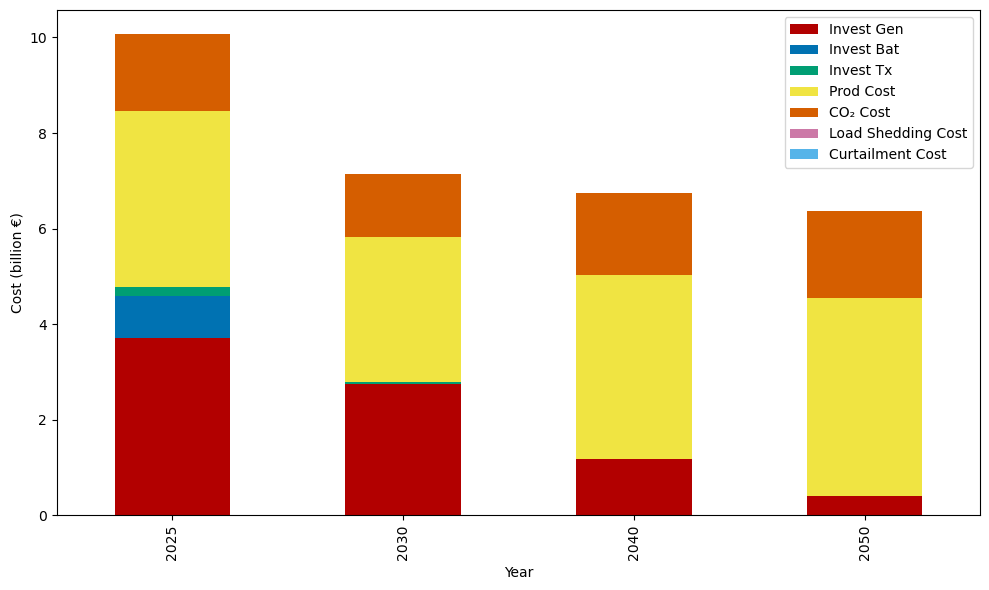

Annual System Costs by Scenario


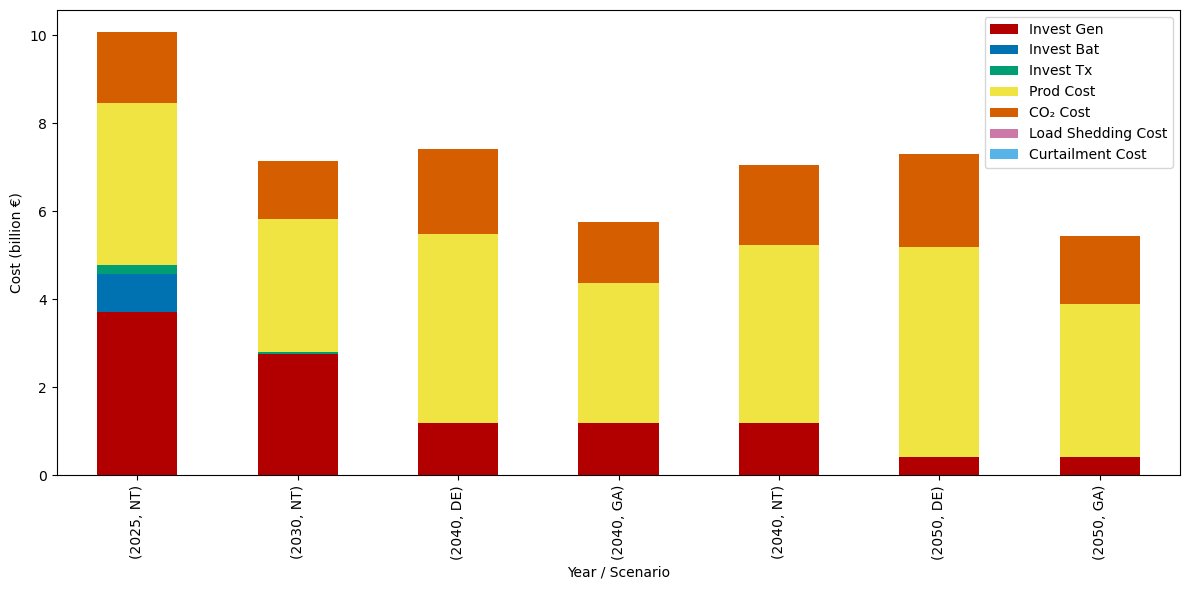

In [63]:
analytics.plot_yearly_costs_stacked_avg(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)
analytics.plot_yearly_costs_stacked_by_scenario(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)

In [64]:
total_system_cost = analytics.compute_total_system_cost(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
total_system_cost

Total system cost by year:


,AIC,expected_OC,total_cost
year,,,
2025,4.783929e+09,5.287230e+09,1.007116e+10
2030,2.793643e+09,4.356679e+09,7.150322e+09
2040,1.179938e+09,5.559010e+09,6.738948e+09
2050,4.100994e+08,5.964731e+09,6.374830e+09


In [65]:
assert (
    abs(total_system_cost["total_cost"].sum() - model_info["Objective Value"][0]) < 1000
), f"Mismatch in total system cost: {total_system_cost['total_cost'].sum():,.0f} vs {model_info['Objective Value'][0]:,.0f}"

In [66]:
mega_table = analytics.make_mega_cost_table(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
mega_table

Invest Gen    Invest Bat     Invest Tx  Production Cost  \
year scenario                                                              
2025 NT        3.700676e+09  8.822622e+08  2.009912e+08     3.669299e+09   
2030 NT        2.753993e+09  0.000000e+00  3.964995e+07     3.036839e+09   
2040 DE        1.179938e+09  0.000000e+00  0.000000e+00     4.314067e+09   
     GA        1.179938e+09  0.000000e+00  0.000000e+00     3.188416e+09   
     NT        1.179938e+09  0.000000e+00  0.000000e+00     4.064151e+09   
2050 DE        4.100994e+08  0.000000e+00  0.000000e+00     4.772991e+09   
     GA        4.100994e+08  0.000000e+00  0.000000e+00     3.493730e+09   
All  All       8.044705e+09  8.822622e+08  2.406412e+08     1.469504e+10   

               CO2 Emission Cost  Load Shedding Cost  Curtailment Cost  \
year scenario                                                            
2025 NT             1.617931e+09                 0.0               0.0   
2030 NT             1.319840e+09                 0.0               0.0   
2040 DE             1.915492e+09                 0.0               0.0   
     GA             1.394568e+09                 0.0               0.0   
     NT             1.800336e+09                 0.0               0.0   
2050 DE             2.127616e+09                 0.0               0.0   
     GA             1.535125e+09                 0.0               0.0   
All  All            6.472607e+09                 0.0               0.0   

               Prod+CO2 Cost   Total CapEx    Total OpEx    Total Cost  
year scenario                                                           
2025 NT         5.287230e+09  4.783929e+09  5.287230e+09  1.007116e+10  
2030 NT         4.356679e+09  2.793643e+09  4.356679e+09  7.150322e+09  
2040 DE         6.229559e+09  1.179938e+09  6.229559e+09  7.409497e+09  
     GA         4.582984e+09  1.179938e+09  4.582984e+09  5.762922e+09  
     NT         5.864487e+09  1.179938e+09  5.864487e+09  7.044424e+09  
2050 DE         6.900607e+09  4.100994e+08  6.900607e+09  7.310706e+09  
     GA         5.028855e+09  4.100994e+08  5.028855e+09  5.438954e+09  
All  All        2.116765e+10  9.167609e+09  2.116765e+10  3.033526e+10

In [67]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,1712.650000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99017.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,3425.300000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99007.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,5137.950000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98997.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,6850.600000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,534.262466,0.000000,0.000000,534.262466,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,299110.224929,0.00,#4adbc8,Run of River,True,134.800000,0.000000,269.600000,539.200000,539.200000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,324.036799,324.036799,972.110398
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35592.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,648.073599,648.073599,1296.147198


In [68]:
# End  by saving the extended generators, transmission lines, and batteries tables to and extended tables folder
if tables_folder:
    # Create the extended tables folder if it doesn't exist
    extended_tables_folder = os.path.join(tables_folder, "extended_tables")
    os.makedirs(extended_tables_folder, exist_ok=True)
    generators.to_csv(
        os.path.join(extended_tables_folder, "extended_generators.csv"), index=True
    )
    branches.to_csv(
        os.path.join(extended_tables_folder, "extended_branches.csv"), index=True
    )
    batteries.to_csv(
        os.path.join(extended_tables_folder, "extended_batteries.csv"), index=True
    )

# Dual Variables Analysis

In [69]:
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))
    print("------------------------")

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 11   0            0.0
                             1            0.0

------------------------
battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


------------------------
battery_discharge_new_max_duals



...

------------------------
load_shedding_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

------------------------
power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0       0.014869
                         1       0.015050

------------------------


In [70]:
# Build a DataFrame of scenario probabilities (p_{ω,y})
prob_rows = []
for year_str, scen_list in scenarios.items():
    year = int(year_str)
    probs = scenario_probabilities[year_str]
    for scen, p in zip(scen_list, probs):
        prob_rows.append({"year": year, "scenario": scen, "p": p})
prob_df = pd.DataFrame(prob_rows).set_index(["year", "scenario"])

prob_df

p
year scenario          
2025 NT        1.000000
2030 NT        1.000000
2040 NT        0.333333
     GA        0.333333
     DE        0.333333
2050 GA        0.500000
     DE        0.500000

In [71]:
# Loop through duals and apply 1/p weighting where appropriate
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))

    # Only apply to duals that vary by scenario
    if "scenario" in df.index.names:
        temp = df.reset_index().merge(prob_df, on=["year", "scenario"], how="left")
        # Compute 1/p weight
        temp["weight"] = 1.0 / temp["p"]
        # Apply weight to the dual values
        temp["dual_value"] = temp["dual_value"] * temp["weight"]

        # Reconstruct a weighted-dual Series with the original index
        weighted = temp.set_index(df.index.names)
        # Display the first two rows
        display(weighted.head(2))
        dual_variables[key] = weighted

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 11   0            0.0
                             1            0.0

dual_value    p  weight
battery   scenario year week hour                         
ES1 0 bat NT       2025 11   0            0.0  1.0     1.0
                             1            0.0  1.0     1.0

battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


...

dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0            0.0  1.0     1.0
                         1            0.0  1.0     1.0

power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0       0.014869
                         1       0.015050

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0       0.014869  1.0     1.0
                         1       0.015050  1.0     1.0

In [72]:
# dual variables
battery_charge_new_max_duals = dual_variables["battery_charge_new_max_duals"]
battery_charge_old_duals = dual_variables["battery_charge_old_duals"]
battery_discharge_new_max_duals = dual_variables["battery_discharge_new_max_duals"]
battery_discharge_old_duals = dual_variables["battery_discharge_old_duals"]
branch_extension_duals = dual_variables["branch_extension_duals"]
branch_flow_old_duals_min = dual_variables["branch_flow_old_duals_min"]
branch_flow_old_duals_max = dual_variables["branch_flow_old_duals_max"]
branch_flow_new_duals_min = dual_variables["branch_flow_new_duals_min"]
branch_flow_new_duals_max = dual_variables["branch_flow_new_duals_max"]
emissions_duals = dual_variables["emissions_duals"]
gen_extension_duals = dual_variables["gen_extension_duals"]
gen_output_new_duals = dual_variables["gen_output_new_duals"]
gen_output_old_duals = dual_variables["gen_output_old_duals"]
load_shedding_duals = dual_variables["load_shedding_duals"]
power_balance_duals = dual_variables["power_balance_duals"]

### Power Balance Duals

In [73]:
node_to_city = {
    "ES1 0": "Murcia",
    "ES1 1": "Bilbao",
    "ES1 2": "Zaragoza",
    "ES1 3": "Seville",
    "ES1 4": "Lugo",
    "ES1 5": "Madrid",
    "ES1 6": "Valencia",
    "ES1 7": "Salamanca",
    "ES1 8": "Barcelona",
    "PT1 0": "Porto",
    "PT1 1": "Lisbon",
}

In [74]:
if SAVE_FIGURES:
    # Create the figures folder if it doesn't exist
    dual_folder = os.path.join(RESULTS_FOLDER, "duals")
    os.makedirs(dual_folder, exist_ok=True)
else:
    dual_folder = None
if SAVE_TABLES:
    # Create the tables folder if it doesn't exist
    dual_tables_folder = os.path.join(tables_folder, "duals")
    os.makedirs(dual_tables_folder, exist_ok=True)
else:
    dual_tables_folder = None

In [75]:
lmp_table = analytics.make_nodal_price_table(
    power_balance_duals, savefolder=dual_tables_folder
)

lmp_table

Annual Average Locational Marginal Prices by Node


node               ES1 0      ES1 1      ES1 2      ES1 3      ES1 4  \
year scenario                                                          
2025 NT        41.627420  41.287384  41.777072  41.527172  41.865615   
2030 NT        39.338783  38.928810  39.399887  39.105642  39.424350   
2040 DE        41.903437  41.643314  42.127132  41.857566  42.198702   
     GA        39.317878  38.939002  39.404631  39.116245  39.435040   
     NT        41.167592  40.877300  41.356215  41.082310  41.417482   
2050 DE        59.482999  59.431951  60.133782  59.797516  60.285215   
     GA        39.884500  39.533378  40.002238  39.712125  40.036047   

node               ES1 5      ES1 6      ES1 7      ES1 8      PT1 0  \
year scenario                                                          
2025 NT        41.980198  42.287535  42.374665  42.175921  42.170972   
2030 NT        39.532251  39.881303  39.903716  39.776041  39.816839   
2040 DE        42.314197  42.641872  42.711802  42.529323  42.646983   
     GA        39.542970  39.886105  39.914536  39.780830  39.855490   
     NT        41.530483  41.861535  41.920724  41.751046  41.862157   
2050 DE        60.449856  60.868540  61.017873  60.707884  60.946173   
     GA        40.145351  40.491015  40.522577  40.384143  40.482071   

node               PT1 1  
year scenario             
2025 NT        42.630347  
2030 NT        40.186961  
2040 DE        43.048486  
     GA        40.227394  
     NT        42.253142  
2050 DE        61.534183  
     GA        40.857104

In [76]:
annual_lmp_table = analytics.make_annual_lmp_table(
    power_balance_duals, savefolder=dual_tables_folder
)
annual_lmp_table

scenario,DE,GA,NT,Average
year,,,,
2025,NaN,NaN,41.973118,41.973118
2030,NaN,NaN,39.572235,39.572235
2040,42.329347,39.583647,41.552726,41.155240
2050,60.423270,40.186413,NaN,50.304842


Average LMP by Year and Scenario (±1 std)


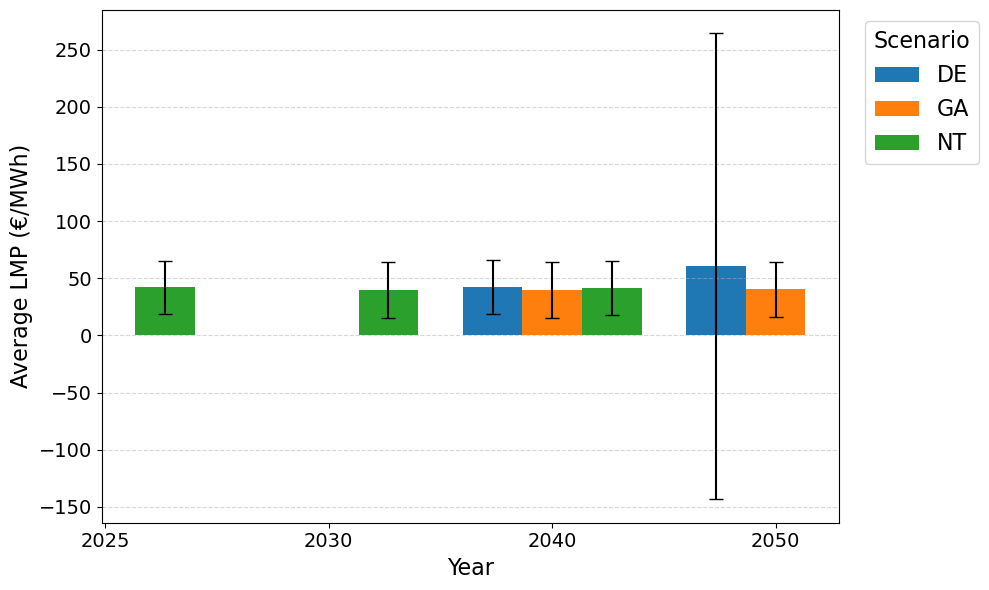

In [77]:
analytics.plot_annual_lmp_by_scenario(power_balance_duals, savefolder=dual_folder)

Average LMP by Year and Scenario


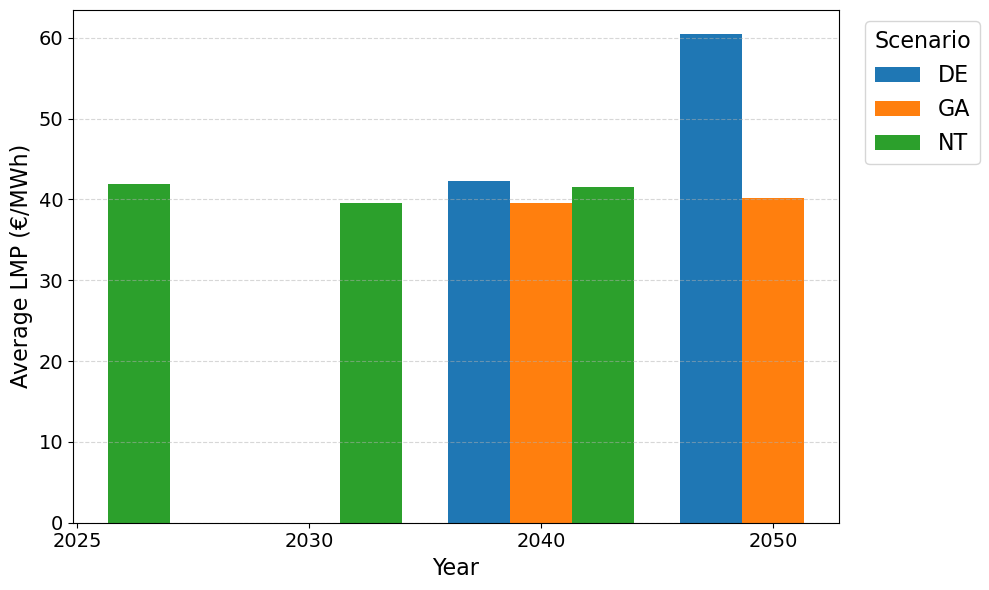

In [78]:
analytics.plot_annual_lmp_by_scenario_simple(
    power_balance_duals, savefolder=dual_folder
)

Average LMP by Year and Scenario (line chart)


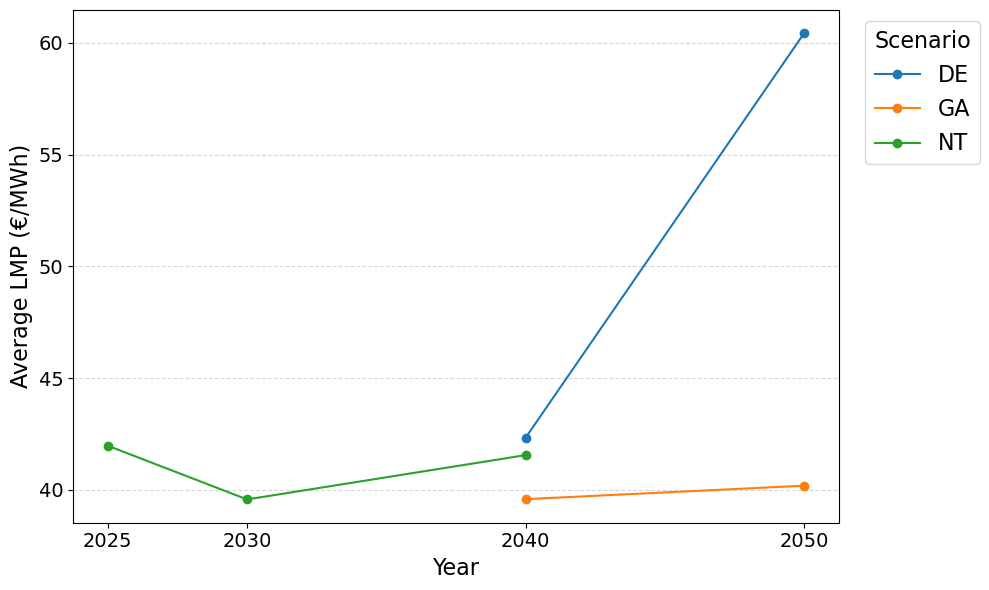

In [79]:
analytics.plot_annual_lmp_by_scenario_line(power_balance_duals, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (with markers)


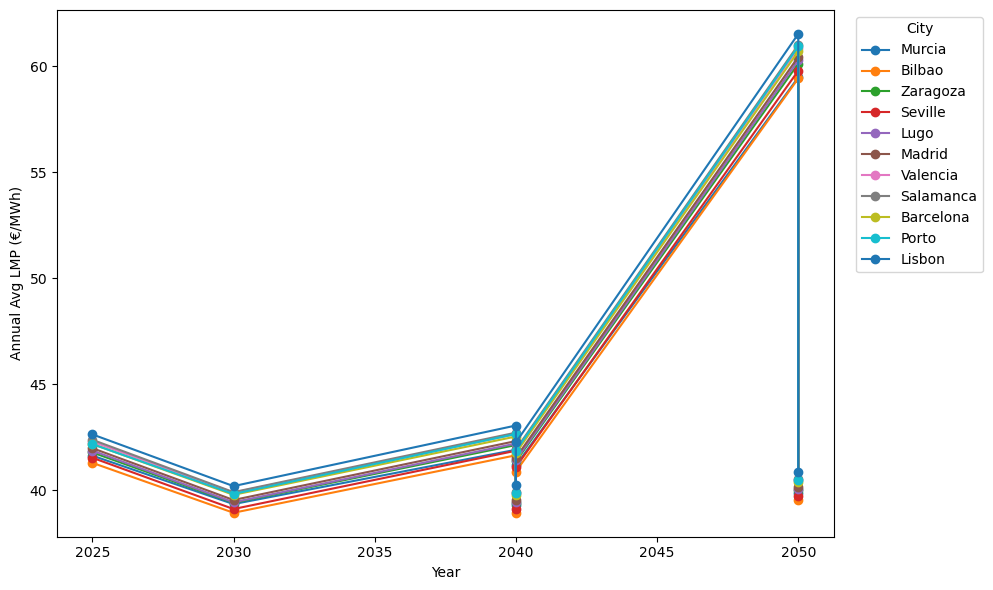

In [80]:
analytics.plot_nodal_price_evolution_with_markers(lmp_table, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (grouped bar)


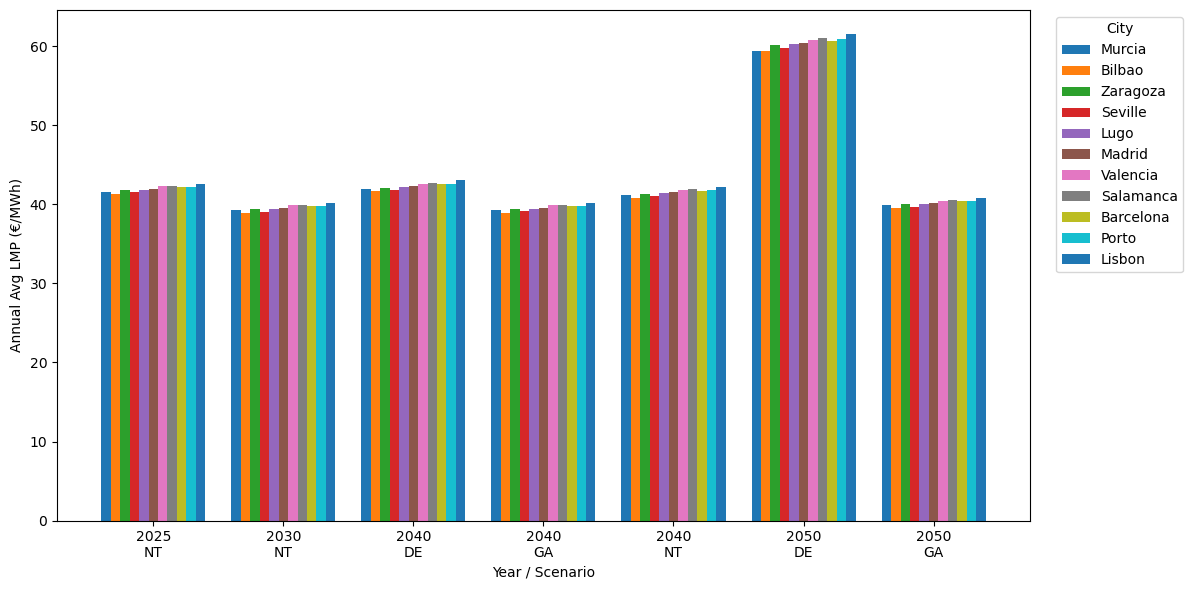

In [81]:
analytics.plot_nodal_price_grouped_bar(
    lmp_table, node_to_city=node_to_city, savefolder=dual_folder
)

In [82]:
branch_extension_duals = branch_extension_duals.rename_axis(index={"branch": "line"})
branch_extension_duals

dual_value
line year             
88   2025 -6017.745902
     2030     0.000000
     2040     0.000000
     2050     0.000000
89   2025     0.000000
...                ...
107  2050     0.000000
219  2025     0.000000
     2030     0.000000
     2040     0.000000
     2050     0.000000

[76 rows x 1 columns]

In [83]:
generators["production_cost"] = (
    generators["marginal_cost"] + generators["co2_emissions"] * CO2_price
)
generators.groupby("carrier")["production_cost"].mean().sort_values(ascending=True)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          55.396970
CCGT          56.520397
Name: production_cost, dtype: float64

In [84]:
for year in power_balance_duals.index.get_level_values("year").unique():
    scen_list = (
        power_balance_duals.xs(year, level="year")
        .index.get_level_values("scenario")
        .unique()
    )
    for scen in scen_list:
        sub = power_balance_duals.xs((scen, year), level=("scenario", "year"))
        vals = sub["dual_value"].values
        print(f"Year: {year}, Scenario: {scen}, max dual: {vals.max()}")

Year: 2025, Scenario: NT, max dual: 60.59023524640168
Year: 2030, Scenario: NT, max dual: 60.221051030739964
Year: 2040, Scenario: NT, max dual: 63.66725991467341
Year: 2040, Scenario: GA, max dual: 61.72488026653937
Year: 2040, Scenario: DE, max dual: 69.64231637112425
Year: 2050, Scenario: GA, max dual: 63.11029326850952
Year: 2050, Scenario: DE, max dual: 2448.363428776768


In [85]:
freqs = analytics.compute_lmp_bucket_frequencies(
    power_balance_duals, generators, dual_tables_folder
)


freqs

LMP Bucket Frequencies


,lower,upper,absolute,relative_percent
bucket,,,,
curtailment,-110.000000,-90.000000,0,0.000000
gap_curtailment_neg_thermal,-90.000000,-62.172437,0,0.000000
neg_thermal,-62.172437,-49.857273,0,0.000000
gap_neg_thermal_neg_wind,-49.857273,-0.016500,0,0.000000
neg_wind,-0.016500,-0.013500,0,0.000000
gap_neg_wind_neg_solar,-0.013500,-0.011000,0,0.000000
neg_solar,-0.011000,-0.009000,0,0.000000
gap_neg_solar_non-binding,-0.009000,-0.000100,0,0.000000
non-binding,-0.000100,0.000100,0,0.000000


LMP Bucket Absolute Frequencies


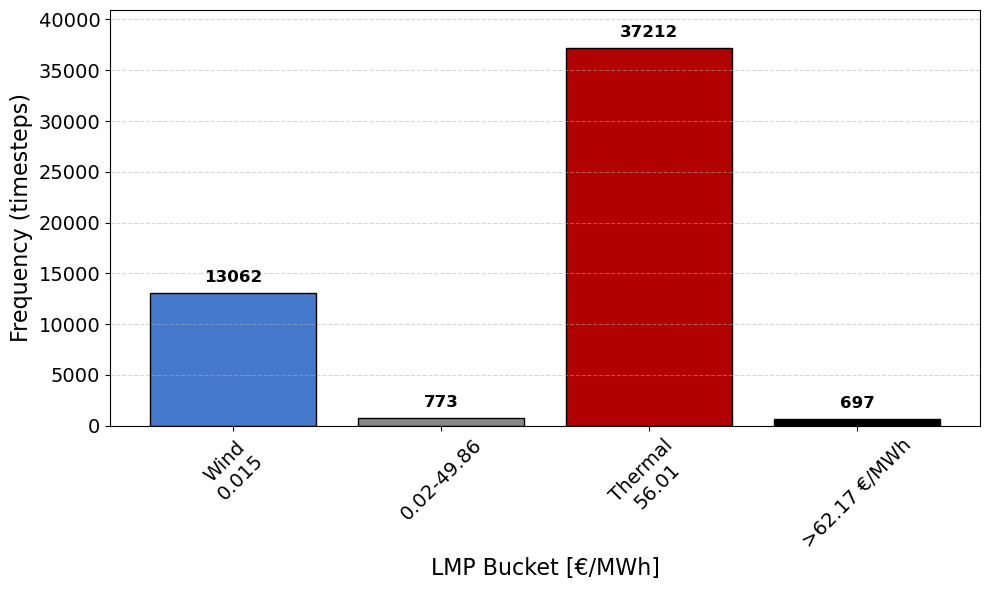

In [86]:
analytics.plot_lmp_bucket_frequencies(freqs, savefolder=dual_folder)

In [87]:
freqs

,lower,upper,absolute,relative_percent
bucket,,,,
curtailment,-110.000000,-90.000000,0,0.000000
gap_curtailment_neg_thermal,-90.000000,-62.172437,0,0.000000
neg_thermal,-62.172437,-49.857273,0,0.000000
gap_neg_thermal_neg_wind,-49.857273,-0.016500,0,0.000000
neg_wind,-0.016500,-0.013500,0,0.000000
gap_neg_wind_neg_solar,-0.013500,-0.011000,0,0.000000
neg_solar,-0.011000,-0.009000,0,0.000000
gap_neg_solar_non-binding,-0.009000,-0.000100,0,0.000000
non-binding,-0.000100,0.000100,0,0.000000


LMP Bucket Relative Frequencies (%)


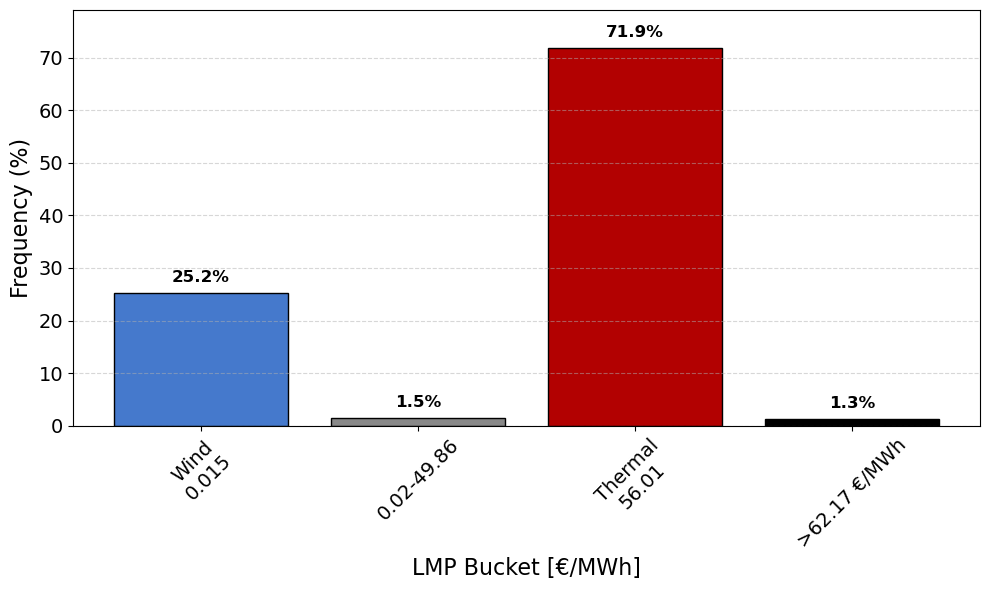

In [88]:
analytics.plot_lmp_bucket_percentages(freqs, savefolder=dual_folder)

In [89]:
for year in power_balance_duals.index.get_level_values("year").unique():
    scen_list = (
        power_balance_duals.xs(year, level="year")
        .index.get_level_values("scenario")
        .unique()
    )
    for scen in scen_list:
        sub = power_balance_duals.xs((scen, year), level=("scenario", "year"))
        vals = sub["dual_value"].values
        print(f"Year: {year}, Scenario: {scen}, max dual: {vals.max()}")

Year: 2025, Scenario: NT, max dual: 60.59023524640168
Year: 2030, Scenario: NT, max dual: 60.221051030739964
Year: 2040, Scenario: NT, max dual: 63.66725991467341
Year: 2040, Scenario: GA, max dual: 61.72488026653937
Year: 2040, Scenario: DE, max dual: 69.64231637112425
Year: 2050, Scenario: GA, max dual: 63.11029326850952
Year: 2050, Scenario: DE, max dual: 2448.363428776768


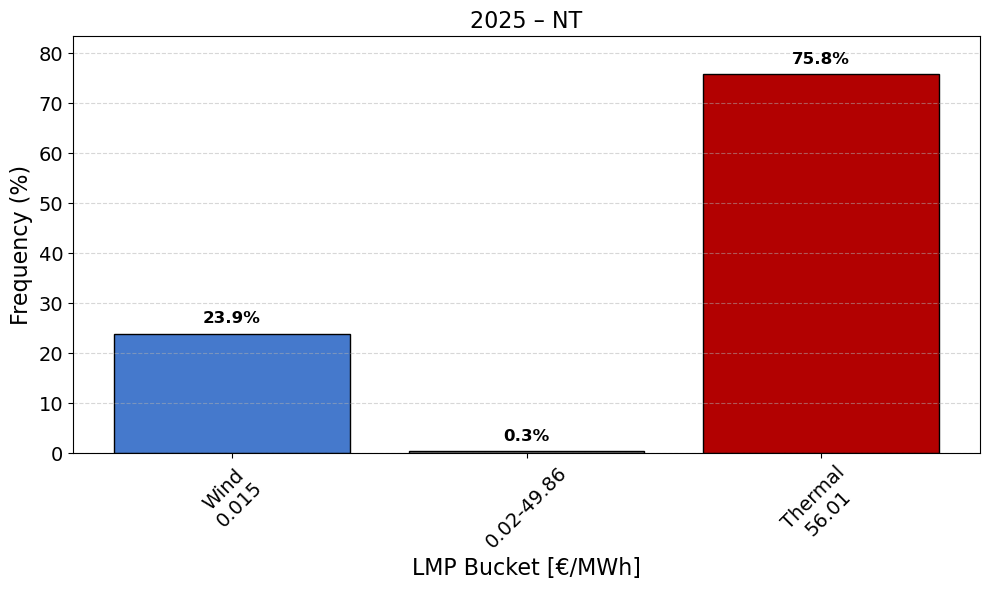

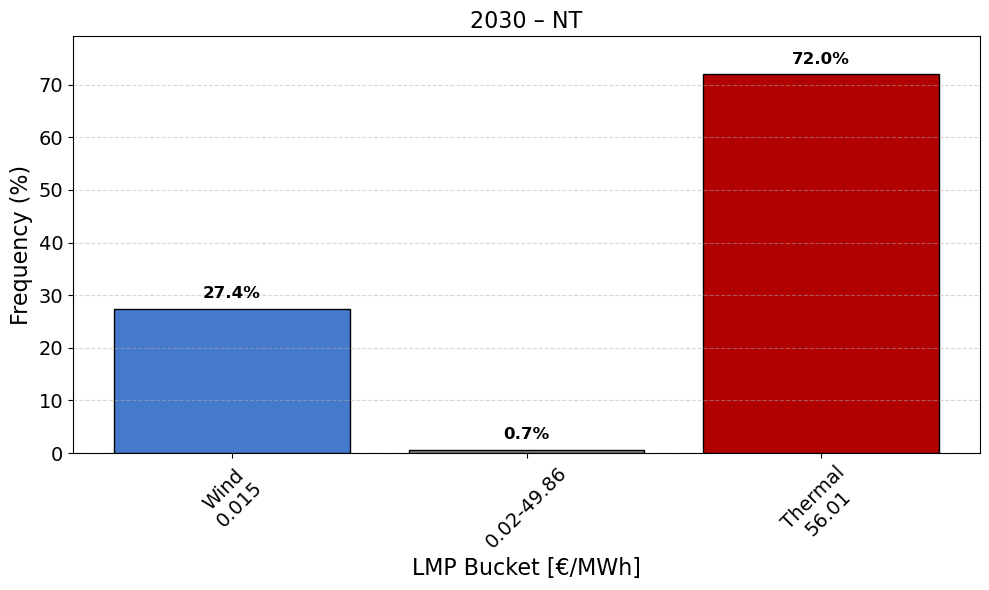

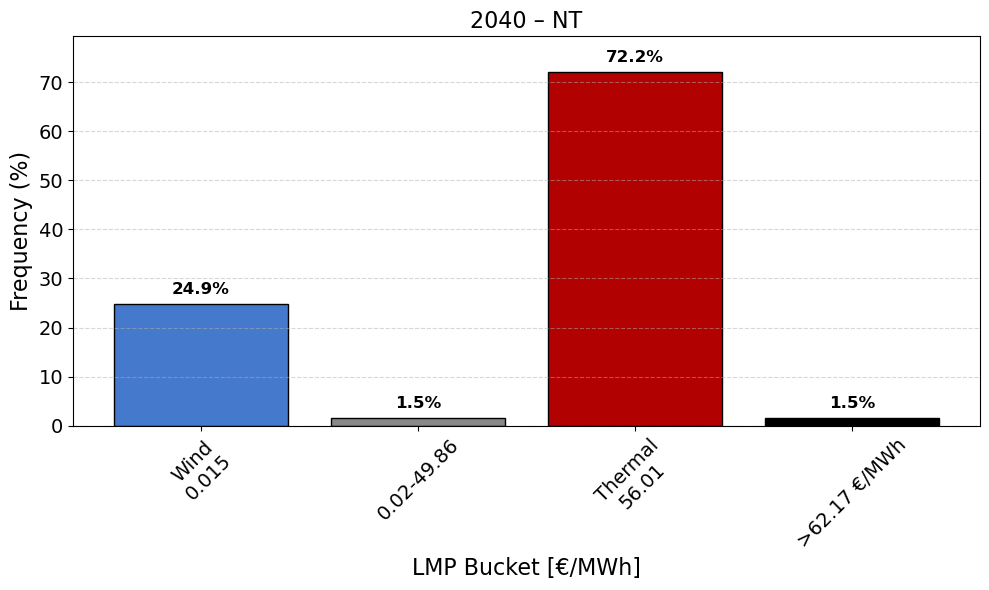

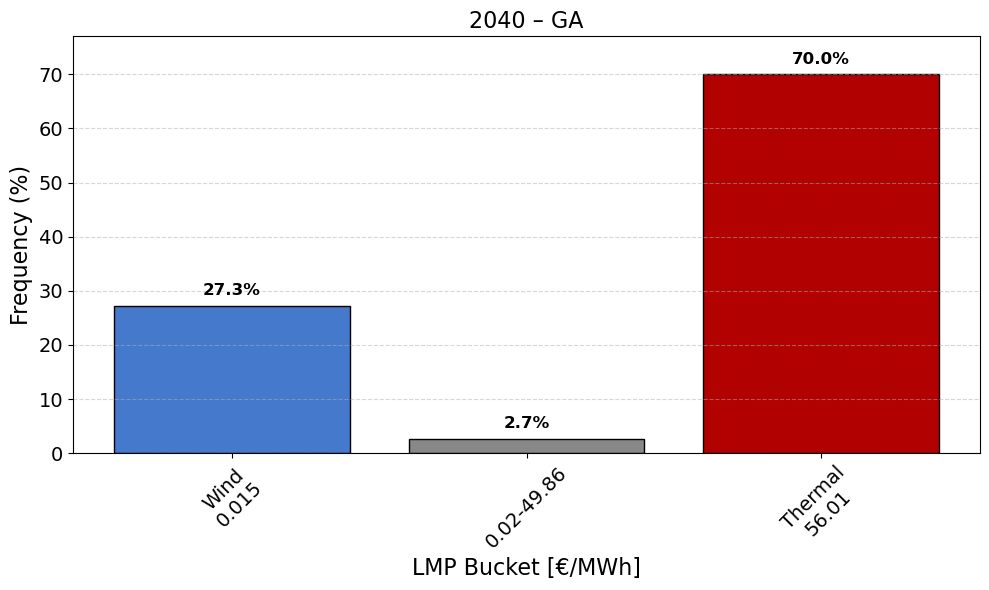

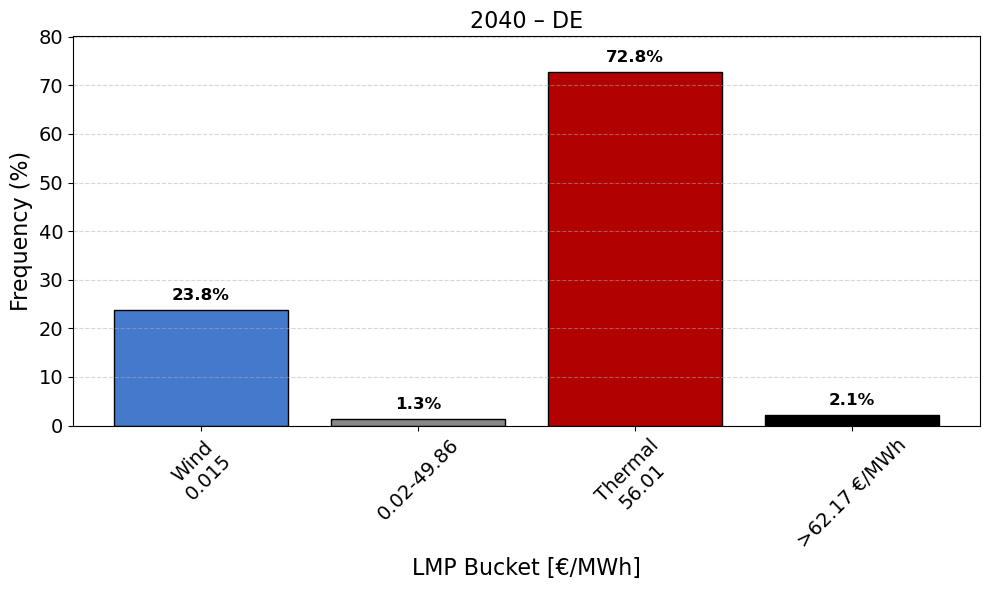

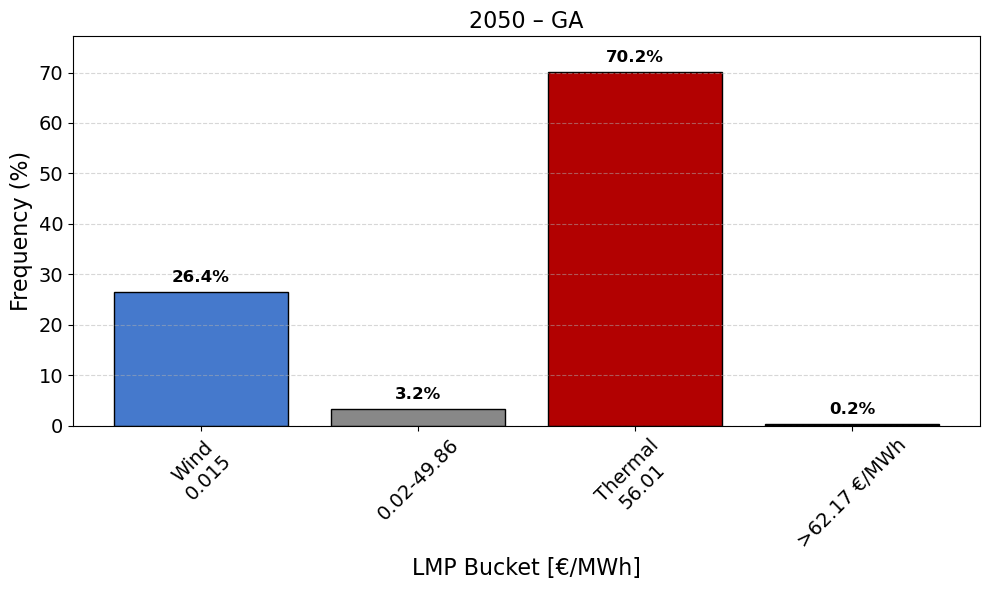

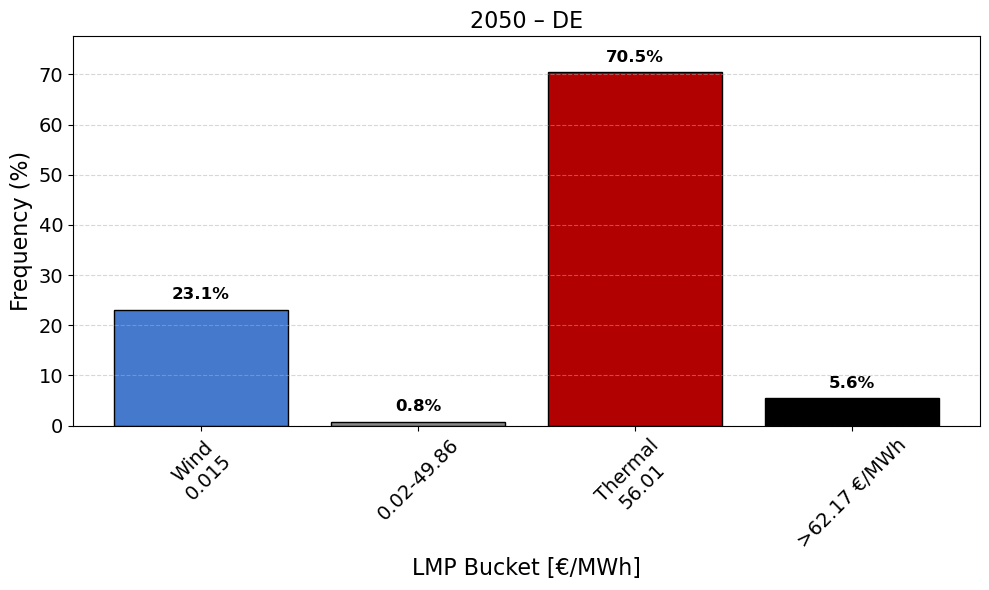

In [90]:
analytics.plot_lmp_bucket_percentages_by_year_scenario(
    power_balance_duals, freqs, savefolder=dual_folder
)

In [91]:
freqs

,lower,upper,absolute,relative_percent
bucket,,,,
curtailment,-110.000000,-90.000000,0,0.000000
gap_curtailment_neg_thermal,-90.000000,-62.172437,0,0.000000
neg_thermal,-62.172437,-49.857273,0,0.000000
gap_neg_thermal_neg_wind,-49.857273,-0.016500,0,0.000000
neg_wind,-0.016500,-0.013500,0,0.000000
gap_neg_wind_neg_solar,-0.013500,-0.011000,0,0.000000
neg_solar,-0.011000,-0.009000,0,0.000000
gap_neg_solar_non-binding,-0.009000,-0.000100,0,0.000000
non-binding,-0.000100,0.000100,0,0.000000


df        year scenario  dual_value
0      2025       NT    0.014869
1      2025       NT    0.015050
2      2025       NT    0.015049
3      2025       NT    0.015049
4      2025       NT    0.015049
...     ...      ...         ...
51739  2050       DE   56.522234
51740  2050       DE   56.524591
51741  2050       DE   56.526947
51742  2050       DE   56.529304
51743  2050       DE   56.360010

[51744 rows x 3 columns]
high        year scenario   dual_value
3112   2040       DE    65.956333
3113   2040       DE    66.536164
3114   2040       DE    66.538938
3115   2040       DE    66.541712
3116   2040       DE    66.544486
...     ...      ...          ...
51497  2050       DE  2448.057249
51498  2050       DE  2448.159305
51499  2050       DE  2448.261365
51500  2050       DE  2448.363429
51501  2050       DE    70.562112

[697 rows x 3 columns]
scenario   DE  GA   NT
year                  
2040      158   0  110
2050      411  18    0
LMP event counts above 62.17 €/MWh by Year & S

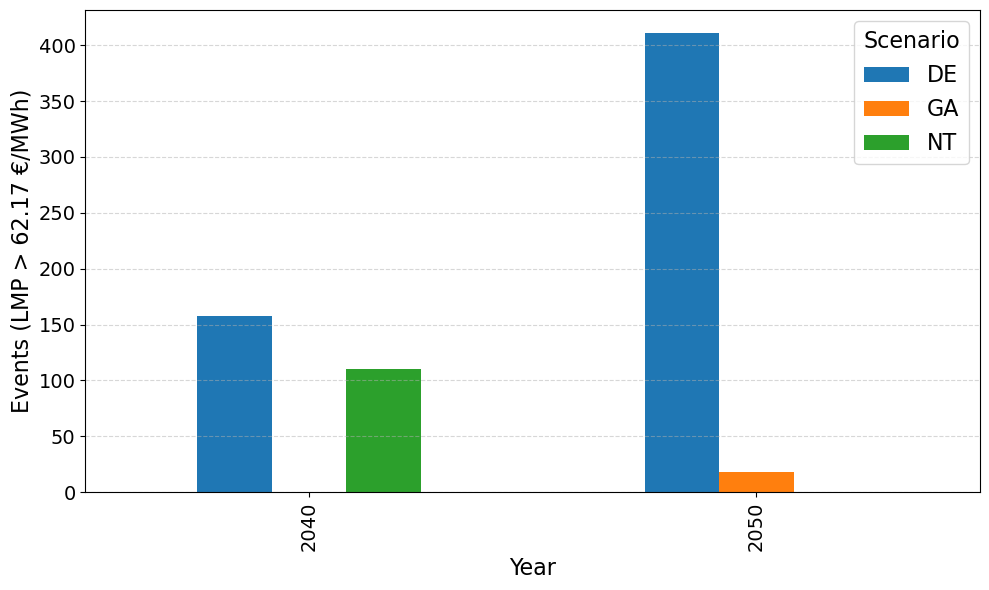

Distribution of LMPs > 62.17 €/MWh


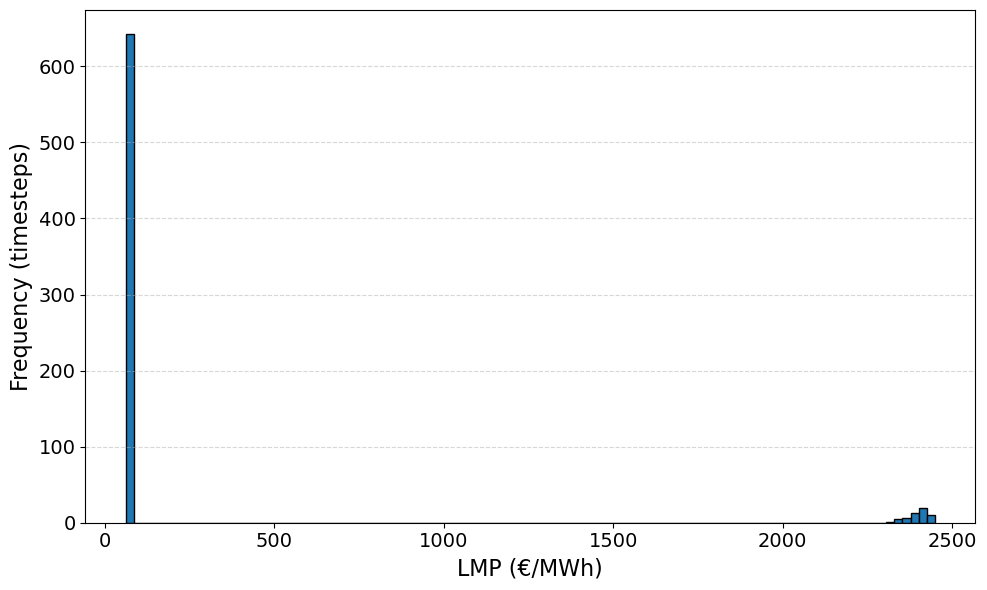

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
49     2409.396     2448.363     22        40.000000          0.042517
48     2370.429     2409.396     21        38.181818          0.040584
47     2331.462     2370.429     11        20.000000          0.021259
46     2292.494     2331.462      1         1.818182          0.001933
36     1902.822     1941.789      0         0.000000          0.000000
27     1552.116     1591.084      0         0.000000          0.000000
28     1591.084     1630.051      0         0.000000          0.000000
29     1630.051     1669.018      0         0.000000          0.000000
30     1669.018     1707.985      0         0.000000          0.000000
31     1707.985     1746.953      0         0.000000          0.000000
Top 5 high-LMP bins by occurrence


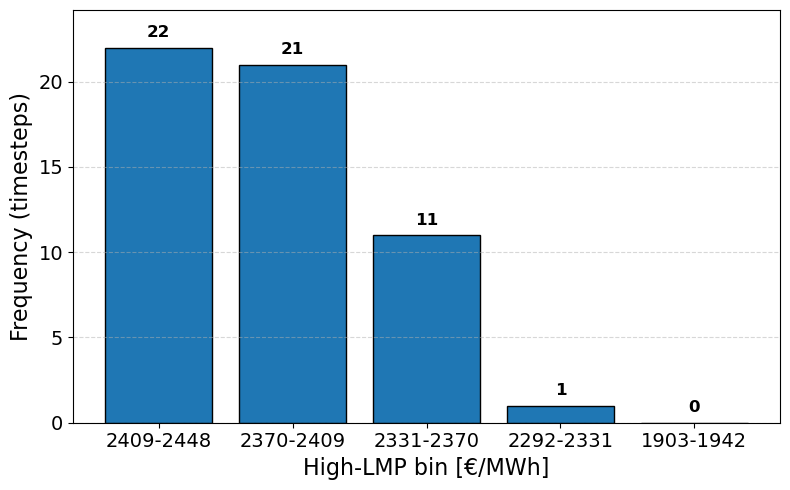

In [92]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:

    cap = freqs.loc[freqs.index != "other", "upper"].max()

    analytics.plot_high_lmp_event_counts(
        power_balance_duals, cap, savefolder=dual_folder
    )

    analytics.plot_high_lmp_distribution(
        power_balance_duals, cap, n_bins=100, savefolder=dual_folder
    )

    high_tbl = analytics.make_high_lmp_frequency_table(
        power_balance_duals, cap=500, n_bins=50, savefolder=dual_tables_folder
    )
    top5 = analytics.get_top_high_lmp_buckets(
        high_tbl, top_n=10, savefolder=dual_tables_folder
    )
    print(top5)
    analytics.plot_top_high_lmp_buckets(high_tbl, top_n=5, savefolder=dual_folder)

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
0        62.171       86.034    642        92.109039          1.240724
98     2400.640     2424.502     20         2.869440          0.038652
97     2376.778     2400.640     13         1.865136          0.025124
99     2424.502     2448.363     10         1.434720          0.019326
96     2352.916     2376.778      6         0.860832          0.011596
95     2329.054     2352.916      5         0.717360          0.009663
94     2305.192     2329.054      1         0.143472          0.001933
4       157.620      181.482      0         0.000000          0.000000
63     1565.473     1589.335      0         0.000000          0.000000
72     1780.230     1804.092      0         0.000000          0.000000
Top 6 high-LMP bins by occurrence


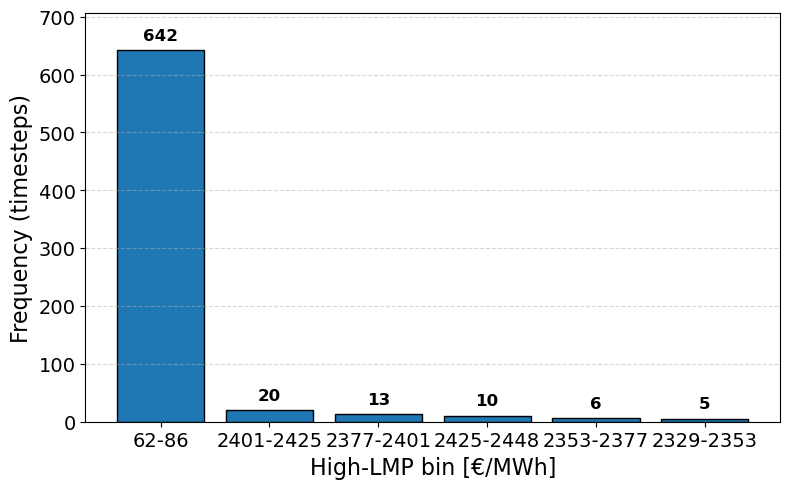

In [93]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    high_tbl = analytics.make_high_lmp_frequency_table(
        power_balance_duals, cap=cap, n_bins=100, savefolder=dual_tables_folder
    )

    top5 = analytics.get_top_high_lmp_buckets(
        high_tbl, top_n=10, savefolder=dual_tables_folder
    )

    print(top5)

    analytics.plot_top_high_lmp_buckets(high_tbl, top_n=6, savefolder=dual_folder)

Detailed histogram for top high-LMP bucket (62.17–86.03 €/MWh)


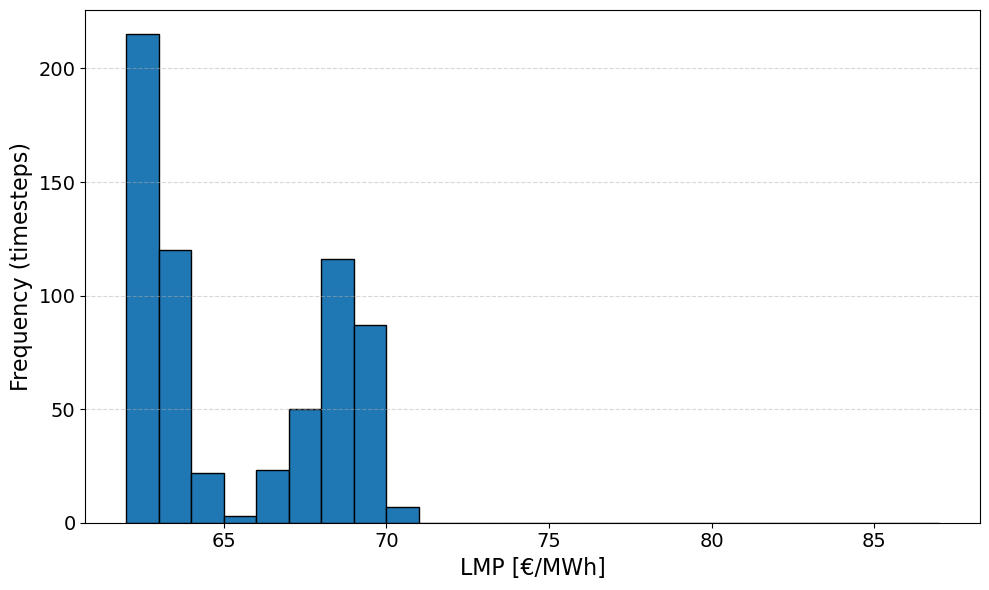

In [94]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    # Assuming you've already built `high_tbl`:

    analytics.plot_top_high_bucket_detail(
        power_balance_duals, high_tbl, width=1.0, savefolder=dual_folder
    )

In [95]:
power_balance_duals

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0       0.014869  1.0     1.0
                         1       0.015050  1.0     1.0
                         2       0.015049  1.0     1.0
                         3       0.015049  1.0     1.0
                         4       0.015049  1.0     1.0
...                                   ...  ...     ...
PT1 1 DE       2050 52   163    56.522234  0.5     2.0
                         164    56.524591  0.5     2.0
                         165    56.526947  0.5     2.0
                         166    56.529304  0.5     2.0
                         167    56.360010  0.5     2.0

[51744 rows x 3 columns]

               count_total  count_bucket  percent_bucket_of_total
year scenario                                                    
2025 NT               7392            25                 0.338203
2030 NT               7392            50                 0.676407
2040 DE               7392            93                 1.258117
     GA               7392           200                 2.705628
     NT               7392           110                 1.488095
2050 DE               7392            59                 0.798160
     GA               7392           236                 3.192641
Distribution of LMPs in bucket 'gap_wind_thermal'


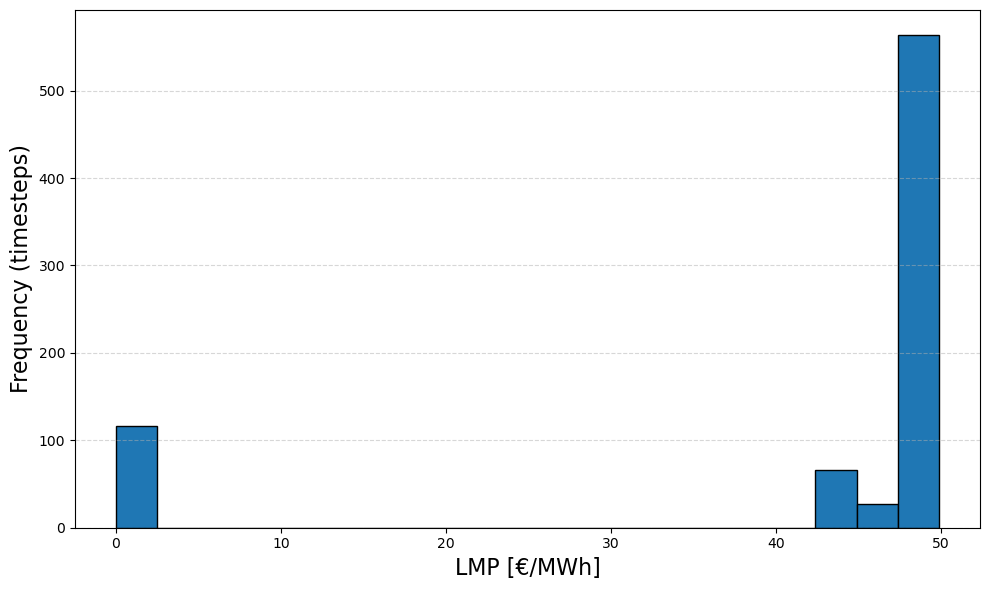

In [96]:
gap_subset = analytics.extract_duals_in_lmp_bucket(
    power_balance_duals, freqs, "gap_wind_thermal"
)
gap_summary = analytics.summarize_gap_duals_by_year_scenario(
    gap_subset, power_balance_duals, savefolder=dual_tables_folder
)
print(gap_summary)
analytics.plot_gap_lmp_distribution(
    gap_subset, "gap_wind_thermal", savefolder=dual_folder
)

LMP ≥ 70 €/MWh: count = 62 timesteps


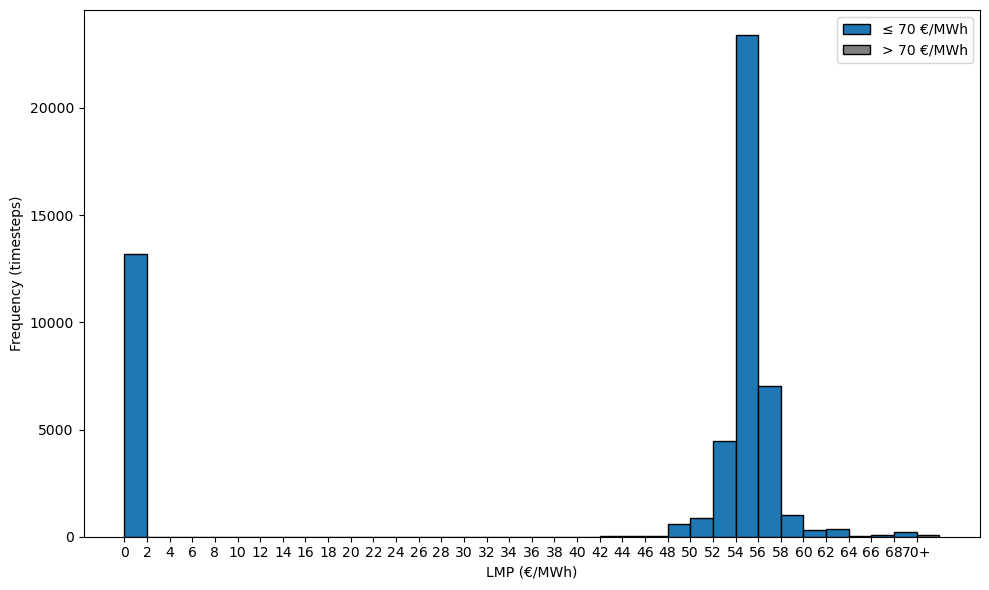

In [97]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    analytics.plot_lmp_histogram_70plus(
        power_balance_duals, cap=70, bin_width=2.0, savefolder=dual_folder
    )

In [98]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    freq_table = analytics.make_lmp_frequency_table(
        power_balance_duals, bin_width=1.0, cap=70, savefolder=dual_tables_folder
    )

    with pd.option_context("display.max_rows", None, "display.max_columns", None):

        sorted_freq_table = freq_table.sort_values(by="count", ascending=False)

        display(sorted_freq_table)

,lower_bound,upper_bound,count,percent,count_2025,count_2030,count_2040,count_2050
54,54.0,55.0,13691,26.459106,2254,2220,5701,3516
0,0.0,1.0,13178,25.467687,1771,2057,5643,3707
55,55.0,56.0,9703,18.751933,1746,1292,4015,2650
56,56.0,57.0,4404,8.511132,779,495,1863,1267
53,53.0,54.0,4051,7.828927,365,803,1803,1080
57,57.0,58.0,2642,5.105906,312,220,1258,852
58,58.0,59.0,836,1.615646,71,55,438,272
50,50.0,51.0,540,1.043599,38,104,205,193
49,49.0,50.0,470,0.908318,18,21,212,219
52,52.0,53.0,435,0.840677,11,57,206,161


In [99]:
generators["production_cost"].groupby(generators["carrier"]).mean().sort_values(
    ascending=True
)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          55.396970
CCGT          56.520397
Name: production_cost, dtype: float64

In [100]:
# plot_top_10_dual_intervals(
#     power_balance_duals, sorted_freq_table, n_bins=10, savefolder=dual_folder
# )
# create_top_10_dual_intervals_tables(
#     power_balance_duals, freq_table, n_bins=10, savefolder=dual_tables_folder
# )

In [101]:
average_duals = power_balance_duals.groupby("year")["dual_value"].mean()
average_duals

year
2025    41.973118
2030    39.572235
2040    41.155240
2050    50.304842
Name: dual_value, dtype: float64

In [102]:
summary_by_carrier = analytics.summarise_extension_status_by_carrier(
    generators, savefolder=generators_save_table_folder
)


summary_by_carrier

Extension status by carrier


extension_status  not extended  partly extended  fully extended
year carrier                                                   
2025 CCGT                    7                1               3
     coal                    5                0               0
     offwind-ac              1                1               7
     onwind                  0                0              11
     ror                     0                0               4
     solar                   0                0              11
2030 CCGT                   10                0               1
     coal                    5                0               0
     offwind-ac              4                0               5
     onwind                  2                0               9
     ror                     0                0               4
     solar                   0                0              11
2040 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              7                0               2
     onwind                  6                0               5
     ror                     4                0               0
     solar                   0                0              11
2050 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              9                0               0
     onwind                 10                0               1
     ror                     4                0               0
     solar                   0                0              11

In [103]:
# Usage example:
summary_table = analytics.summarize_dual_nonzero_counts(
    dual_variables, dual_tables_folder
)
summary_table

,total_duals,nonzero_duals,percent_nonzero
dual,,,
battery_charge_new_max_duals,51744,1470,2.840909
battery_charge_old_duals,0,0,0.000000
battery_discharge_new_max_duals,51744,401,0.774969
battery_discharge_old_duals,0,0,0.000000
branch_extension_duals,76,2,2.631579
branch_flow_new_duals_max,89376,12654,14.158163
branch_flow_new_duals_min,89376,32265,36.100295
branch_flow_old_duals_max,89376,12636,14.138024
branch_flow_old_duals_min,89376,32243,36.075680


In [104]:
summary = analytics.summarize_duals_by_year_scenario(
    dual_variables, savefolder=dual_tables_folder
)

with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", None
):

    display(summary)

total_duals  nonzero_duals  \
dual                            year scenario                               
battery_charge_new_max_duals    2025 NT               7392            233   
                                2030 NT               7392            179   
                                2040 DE               7392            107   
                                     GA               7392            279   
                                     NT               7392            137   
                                2050 DE               7392            314   
                                     GA               7392            221   
battery_discharge_new_max_duals 2025 NT               7392             50   
                                2030 NT               7392             60   
                                2040 DE               7392             55   
                                     GA               7392             48   
                                     NT               7392             51   
                                2050 DE               7392             68   
                                     GA               7392             69   
branch_extension_duals          2025 All                19              2   
                                2030 All                19              0   
                                2040 All                19              0   
                                2050 All                19              0   
branch_flow_new_duals_max       2025 NT              12768           1778   
                                2030 NT              12768           1675   
                                2040 DE              12768           1856   
                                     GA              12768           1754   
                                     NT              12768           1848   
                                2050 DE              12768           1933   
                                     GA              12768           1810   
branch_flow_new_duals_min       2025 NT              12768           4667   
                                2030 NT              12768           4700   
                                2040 DE              12768           4579   
                                     GA              12768           4617   
                                     NT              12768           4568   
                                2050 DE              12768           4532   
                                     GA              12768           4602   
branch_flow_old_duals_max       2025 NT              12768           1771   
                                2030 NT              12768           1670   
                                2040 DE              12768           1852   
                                     GA              12768           1751   
                                     NT              12768           1848   
                                2050 DE              12768           1934   
                                     GA              12768           1810   
branch_flow_old_duals_min       2025 NT              12768           4661   
                                2030 NT              12768           4700   
                                2040 DE              12768           4578   
                                     GA              12768           4616   
                                     NT              12768           4566   
                                2050 DE              12768           4522   
                                     GA              12768           4600   
emissions_duals                 2025 NT                  1              0   
                                2030 NT                  1              0   
                                2040 DE                  1              0   
                                     GA                  1              0   
                                     NT    

In [105]:
nz = analytics.list_nonzero_gen_extension_duals(
    gen_extension_duals, savefolder=dual_tables_folder
)

nz

dual_value
year generator                      
2025 ES1 4 offwind-ac -414624.178698
     ES1 4 onwind     -300240.329509
     PT1 1 ror        -282177.928323
     PT1 0 ror        -276445.290327
     ES1 2 onwind     -261750.632262
...                              ...
2050 ES1 7 solar       -24711.274568
     PT1 0 solar       -18145.143301
     ES1 4 solar       -13068.060248
     ES1 1 solar       -12324.061986
     ES1 4 onwind       -8554.749772

[96 rows x 1 columns]

In [106]:
generators.groupby("carrier")["capital_cost"].mean()

carrier
CCGT           99012.729293
coal          349961.553630
offwind-ac    184181.306769
onwind         96070.888020
ror           299125.224929
solar          35587.071244
Name: capital_cost, dtype: float64